# Many-body Bell correlators

**Marcin Płodzień** — Institute of Theoretical Physics, Jagiellonian University in Kraków  
[ORCID 0000-0002-0835-1644](https://orcid.org/0000-0002-0835-1644) · [github.com/MarcinPlodzien](https://github.com/MarcinPlodzien) · [www](https://chaos.if.uj.edu.pl/marcinplodzien/)

*Quantum Many-Body Simulation — Chapter 9 — Entanglement and complexity diagnostics*

## 1. Introduction and motivation

A Bell inequality is a bound on correlations that follows from one assumption only: that the outcomes of the measurements
already exist before the measurements are made, and that each party's outcome depends on that party's setting and on shared
information from the past, not on what the other parties chose. Any theory of this kind is called a **local hidden-variable
(LHV)** model. Quantum mechanics violates such bounds, which is why they matter: a violated Bell inequality is a
device-independent certificate — it says something about the physics without assuming anything about the apparatus.

[Notebook 19](../ch08_quantum_information_protocols/19_bell_states_and_chsh.ipynb) derived the archetype, the CHSH
inequality for two parties: the classical bound is $2$ and quantum mechanics reaches $2\sqrt2$. This notebook asks the same
question for $N$ parties at once. The change has consequences. With two parties there is one way to be entangled; with $N$
there is a whole hierarchy, and a many-body Bell inequality can distinguish between "somewhere in this system there are two
correlated particles" and "all $N$ particles participate in one correlated object". The quantities that do this are the
objects of the last decade of research in quantum metrology and in cold-atom experiments, where the states are produced by
collective interactions and the individual particles cannot be addressed at all.

The correlator we study is built from one operator per site,

$$\mathcal B(\boldsymbol\theta)=\bigotimes_{k=0}^{N-1}\tilde\sigma^{-}_{k},\qquad
  \tilde\sigma^{-}_k=U_k\,\sigma^{-}\,U_k^{\dagger},\qquad \sigma^{-}=\vert1\rangle\langle0\vert , \tag{1}$$

with an independent local unitary $U_k$ on every site, and the quantity of interest is

$$\mathcal E=\max_{\{U_k\}}\bigl\vert\langle\mathcal B\rangle\bigr\vert^2 . \tag{2}$$

At first sight Eq. (1) has nothing to do with Bell inequalities: $\sigma^-$ is not even Hermitian, so it is not an
observable. Section 4 shows that it is a disguise: $\tilde\sigma^-=\tfrac12(A+iB)$ where $A$ and $B$ are two *orthogonal*
dichotomic observables — exactly the two measurement settings each party has in a Bell test — so Eq. (2) is a specific
complex combination of the $2^N$ ordinary correlation functions that an $N$-party Bell experiment measures. Two bounds then
follow by direct calculation:

$$\mathcal E\le2^{-N}\quad\text{(every local hidden-variable model)},\qquad
  \mathcal E\le4^{-N}\quad\text{(every fully separable quantum state)} ,$$

while the algebraic maximum over *all* states is $\mathcal E=1/4$, reached by the GHZ state. Taking logarithms turns the two
bounds into a pair of numbers that are positive exactly when the corresponding bound is violated:

$$Q_{\rm B}=\log_2\mathcal E+N ,\qquad Q_{\rm E}=\tfrac12\log_2\mathcal E+N . \tag{3}$$

$Q_{\rm B}>0$ certifies Bell correlations; $Q_{\rm E}>0$ certifies entanglement; and $Q_{\rm B}\le N-2$,
$Q_{\rm E}\le N-1$ always, with equality for GHZ.

**Road map.** Section 3 recalls what a Bell inequality is and states CHSH. Section 4 builds the correlator and *derives*
both bounds, together with the bound for states that factorise into $m$ groups (which certifies genuine $N$-partite
entanglement). Section 5 turns Eq. (2) into two array lookups: because $\sigma^-{}^{\otimes N}=\vert1\cdots1\rangle\langle
0\cdots0\vert$, the whole expectation value is one matrix element of the locally rotated state, costing $O(N2^N)$ instead of
$O(4^N)$. Section 6 derives closed forms for product, GHZ, W and Dicke states and verifies them. Section 7 is the
optimisation problem: two angles per site, `jax.grad` plus Adam, `vmap` over random restarts, compared with SPSA and with the
analytic optimum, plus a look at the landscape. Section 8 runs the test states of the scope, including graph states and
$T$-doped graph states, and explains why some of them must give identical answers. Section 9 puts noise on the density
tensor and derives the critical noise strength for each channel and each bound. Section 10 replaces the density tensor by
quantum trajectories, derives the bias of the naive estimator of a *nonlinear* function of a Monte-Carlo average, corrects
it, and puts bootstrap error bars on the result. Section 11 evaluates the correlator along a one-axis-twisting evolution and
reports when each bound is crossed.

### What you will learn

*Physics*

* what a Bell inequality is for $N$ parties, and why a single number can separate "entangled" from "Bell-correlated";
* the derivation of the local-realistic bound $2^{-N}$, of the $m$-group separability bound $4^{-m}$ and of the algebraic
  maximum $1/4$;
* closed forms: $\mathcal E=4^{-N}$ for $\vert+\rangle^{\otimes N}$ (the separability bound is *saturated*, with no
  violation), $\mathcal E=1/4$ for GHZ, $\mathcal E=\binom{N}{m}^24^{-N}$ for Dicke states (hence $\mathcal E=N^24^{-N}$
  for W);
* why the correlator is invariant under local unitaries, so that a graph state and the same graph state with a $T$ gate on
  every qubit are indistinguishable by it — and remain so under local dephasing, depolarising and amplitude damping,
  because all three channels commute with the diagonal $T$ gate, while the same channels do separate other pairs of
  locally equivalent states;
* how fast Bell correlations die under dephasing, depolarising and amplitude damping, and why the Bell bound is much more
  fragile than the entanglement bound;
* that one-axis twisting generates Bell correlations, and at what time each bound is crossed.

*Numerical methods*

* matrix-free evaluation of a product of $N$ non-Hermitian single-site operators;
* gradient-based maximisation over $2N$ angles with `jax.grad`, Adam and random restarts, against SPSA;
* the bias of $\vert\bar z\vert^2$ as an estimator of $\vert\mathbb E z\vert^2$, its exact correction, and bootstrap error
  bars for a nonlinear function of a Monte-Carlo average;
* density tensor ($O(4^N)$) against quantum trajectories ($O(M2^N)$) for the same noisy physics.

*Implementation practice*

* writing a cost function that is simultaneously `jit`-able, `grad`-able and `vmap`-able, and batching the restarts;
* `lax.scan` for the optimiser loop so that the graph is compiled once, not unrolled 200 times;
* separating "what the optimiser found" from "what the state can give" by always comparing against an analytic optimum.

### Prerequisites
* [01 — JAX](../ch01_computational_toolbox/01_jax_from_scratch.ipynb) and
  [02 — einsum from scratch](../ch01_computational_toolbox/02_einsum_from_scratch.ipynb);
* [19 — Bell states and CHSH](../ch08_quantum_information_protocols/19_bell_states_and_chsh.ipynb): local hidden variables,
  the CHSH bound $2$, the Tsirelson bound $2\sqrt2$ — we build directly on it;
* [07 — density matrices and quantum channels](../ch03_matrix_free_engine/07_density_matrices_and_quantum_channels.ipynb)
  and [17 — Monte-Carlo wave function](../ch06_open_quantum_systems/17_monte_carlo_wave_function.ipynb) for Sections 9–10;
* [22 — GHZ states and decoherence](../ch08_quantum_information_protocols/22_ghz_states_and_decoherence.ipynb): the GHZ
  coherence and its fragility, which is what Section 9 measures again through a different quantity;
* [25 — entanglement negativity](25_entanglement_negativity.ipynb) is the companion diagnostic of this chapter: the
  negativity detects entanglement across one cut, the Bell correlator detects it in all parties at once;
* [41 — optimizers](../ch11_variational_quantum_circuits/41_optimizers.ipynb) for Adam and SPSA;
* [33 — spin squeezing and one-axis twisting](../ch10_quantum_metrology_protocols/33_spin_squeezing_one_axis_twisting.ipynb)
  and [34 — from OAT to GHZ](../ch10_quantum_metrology_protocols/34_oat_to_ghz_full_metrology_protocol.ipynb) for Section 11.

**Conventions.** Qubit $q$ = tensor axis $q$, counted from $0$; $\vert0\rangle$ is the $+1$ eigenstate of $Z$;
$\sigma^\pm=(X\pm iY)/2$, so that $\sigma^{-}=\vert1\rangle\langle0\vert$ lowers spin up $\vert0\rangle$ to spin down $\vert1\rangle$ and
$\sigma^{+}=\vert0\rangle\langle1\vert$ raises it. Logarithms in Eq. (3) are base $2$.

## Configuration

Every notebook of this course starts with the same cell. Choose where to run (`DEVICE`) and the floating-point precision (`PRECISION`): `"double"` = `float64/complex128` (default, recommended for physics), `"single"` = `float32/complex64` (half the memory, faster on consumer GPUs, but watch the round-off). All code below derives its dtypes from `RDTYPE`/`CDTYPE` and its check tolerances from `TOL`, so nothing else needs to change.

In [1]:
# ==============================================================================
# CONFIGURATION  -- adapt to your hardware, then run the notebook top to bottom
# ==============================================================================
DEVICE    = "auto"     # "auto": use a GPU if JAX finds one, else CPU | "cpu" | "gpu"
PRECISION = "double"   # "double": float64/complex128 | "single": float32/complex64

import os
if DEVICE == "cpu":
    os.environ["JAX_PLATFORMS"] = "cpu"          # must be set BEFORE jax is imported

import os
import string
from functools import partial

import math
import numpy as np
import jax
import jax.numpy as jnp
from jax import lax

# Precision is configurable: "double" = float64/complex128 (default; needed for long time evolutions and
# tight validation), "single" = float32/complex64 (half the memory, faster on consumer GPUs).
# In a notebook PRECISION is defined in the Configuration cell; for this module use the env var QE_PRECISION.
PRECISION = globals().get("PRECISION", os.environ.get("QE_PRECISION", "double"))
jax.config.update("jax_enable_x64", PRECISION == "double")
RDTYPE = jnp.float64 if PRECISION == "double" else jnp.float32       # real dtype
CDTYPE = jnp.complex128 if PRECISION == "double" else jnp.complex64  # complex dtype of all states/operators
TOL = 1e-10 if PRECISION == "double" else 1e-4                       # tolerance for sanity checks (asserts)
_LETTERS = string.ascii_letters  # 52 einsum labels; a call needs (axes + new labels) <= 52: apply_gate on a state
                                 # N + k <= 52 (N <= 51 for k = 1), apply_gate_dm 2N + k <= 52 (N <= 25 for k = 1, 2),
                                 # apply_kraus_dm 2N + 2k + 1 <= 52 (N <= 24 for k = 1, N <= 23 for k = 2)

import time
import matplotlib.pyplot as plt

if DEVICE == "gpu" and jax.default_backend() == "cpu":
    print("WARNING: DEVICE='gpu' requested but JAX found no GPU -- running on CPU.")
print(f"JAX {jax.__version__} | backend: {jax.default_backend()} | devices: {jax.devices()}")
print(f"precision: {PRECISION} -> real {RDTYPE.__name__}, complex {CDTYPE.__name__}, check tolerance TOL={TOL:g}")


JAX 0.11.0 | backend: cpu | devices: [CpuDevice(id=0)]
precision: double -> real float64, complex complex128, check tolerance TOL=1e-10


## 2. Engine recap and helpers

We need the gate primitives for state vectors and density tensors, the standard states, the noise channels in both their
density-matrix and trajectory form, the Adam and SPSA routines, and the exact one-axis-twisting evolution.

In [2]:
#| code-fold: true
#| code-summary: "Engine recap — the simulator primitives used in this notebook (click to expand)"
# ==============================================================================
# ENGINE RECAP: the functions of quantum_engine.py (SmoQ.jax) used in this notebook.
# Each one is derived, with its mathematics and an independent check, in notebook 08b
# (Chapter 3), 'Building the quantum simulator engine'.
# States are rank-N tensors of shape (2,)*N; every operator acts through ONE einsum.
# ==============================================================================
# ----------------------------------------------------------------------------
# 1. Elementary matrices: Paulis, Clifford generators, rotations
# ----------------------------------------------------------------------------
I2 = jnp.eye(2, dtype=CDTYPE)
X = jnp.array([[0, 1], [1, 0]], dtype=CDTYPE)
Y = jnp.array([[0, -1j], [1j, 0]], dtype=CDTYPE)
Z = jnp.array([[1, 0], [0, -1]], dtype=CDTYPE)
H = jnp.array([[1, 1], [1, -1]], dtype=CDTYPE) / jnp.sqrt(2.0)      # Hadamard: Z-basis <-> X-basis
S = jnp.array([[1, 0], [0, 1j]], dtype=CDTYPE)                      # phase gate, S^2 = Z
T = jnp.array([[1, 0], [0, jnp.exp(1j * jnp.pi / 4)]], dtype=CDTYPE)  # pi/8 gate, T^2 = S (non-Clifford!)
SP = jnp.array([[0, 1], [0, 0]], dtype=CDTYPE)  # sigma^+ = |0><1| = (X + iY)/2 : spin raising |1> -> |0>, the decay jump operator
SM = SP.conj().T                                # sigma^- = |1><0| = (X - iY)/2 : spin lowering |0> -> |1>
PAULI = {"I": I2, "X": X, "Y": Y, "Z": Z}
CZ = jnp.diag(jnp.array([1, 1, 1, -1], dtype=CDTYPE))
def ry(theta):
    """Rotation about y:  Ry(theta) = exp(-i theta Y/2) = [[cos, -sin], [sin, cos]](theta/2)  (real matrix)."""
    c, s = jnp.cos(theta / 2), jnp.sin(theta / 2)
    return jnp.array([[c, -s], [s, c]], dtype=CDTYPE)

def rz(theta):
    """Rotation about z:  Rz(theta) = exp(-i theta Z/2) = diag(e^{-i theta/2}, e^{+i theta/2})."""
    e = jnp.exp(-0.5j * theta)
    return jnp.array([[e, 0], [0, jnp.conj(e)]], dtype=CDTYPE)


# ----------------------------------------------------------------------------
# 2. THE core primitive: a k-qubit operator acting on a tensor through ONE einsum
# ----------------------------------------------------------------------------
def apply_gate(psi, U, qubits):
    """Apply a k-qubit operator U to the axes `qubits` of the tensor `psi`.

    MATH
    ----
    One qubit (k=1), target q:
        psi'[s_0,..,a,..,s_{N-1}] = sum_b  U[a,b] psi[s_0,..,b,..,s_{N-1}]
    Two qubits (k=2), targets (q1,q2); the 4x4 matrix is reshaped to U[a1,a2,b1,b2]:
        psi'[.., a1, .., a2, ..] = sum_{b1,b2} U[a1,a2,b1,b2] psi[.., b1, .., b2, ..]
    This IS the action of (1 x .. x U x .. x 1) -- written without ever building it.

    EINSUM TRANSLATION  (generated automatically below)
    ------------------
        N=3, q=1        :  "db,abc->adc"          d = new (output) index of qubit 1
        N=4, q=(1,3)    :  "efbd,abcd->aecf"      e,f = new indices of qubits 1 and 3
    Recipe: label the axes of psi with letters a,b,c,...; give every target qubit a NEW
    letter (the next unused ones); U carries (new letters)+(old letters of the targets); the
    output is psi's labels with the target letters replaced by the new ones.

    IMPLEMENTATION NOTES
    --------------------
    * reshape of U:  (2^k,2^k) -> (2,)*2k.  Row index = (a1..ak), column = (b1..bk), and
      the FIRST qubit in `qubits` is the most significant bit of the small matrix, i.e. it
      corresponds to the LEFT factor of kron(A,B).
    * `qubits` may be any distinct axes in any order: non-neighbouring gates cost the same.
    * U need not be unitary: projectors, Kraus operators and Hamiltonian terms reuse this.
    * psi may be ANY tensor with those axes of size 2: a state (rank N), a density tensor
      (rank 2N: ket axes 0..N-1, bra axes N..2N-1), ...
    COST   O(2^k * 2^N) operations, O(2^N) memory  (dense matrix: O(4^N) both).
    JAX    `qubits` must be static Python ints (they define the einsum string); psi and U are
           traced, so the function can sit inside jit / grad / vmap / scan.
    """
    qubits = tuple(int(q) for q in qubits)
    k, n = len(qubits), psi.ndim
    U = jnp.asarray(U, dtype=psi.dtype).reshape((2,) * (2 * k))     # matrix -> rank-2k tensor
    inp = list(_LETTERS[:n])                                         # labels of psi's axes
    new = _LETTERS[n:n + k]                                          # fresh labels for the outputs
    out = inp.copy()
    for a, q in zip(new, qubits):
        out[q] = a                                                   # target axes get the new labels
    sub = f"{''.join(new)}{''.join(inp[q] for q in qubits)},{''.join(inp)}->{''.join(out)}"
    return jnp.einsum(sub, U, psi)

def apply_gate_dm(rho, U, qubits):
    """Unitary on a density tensor:  rho -> U rho U^dagger.

    MATH   rho'[a..;a'..] = sum_{b,b'} U[a,b] rho[b..;b'..] U^*[a',b']
           i.e. U acts on the KET axis q and the complex conjugate U^* on the BRA axis N+q.
           (A density matrix is "a state vector of 2N qubits": vectorisation |rho>> and
           U (x) U^* acting on it.)
    IMPLEMENTATION  two calls of `apply_gate` -- the same einsum machinery, no new code.
    COST   O(2^k 4^N).
    """
    N = rho.ndim // 2
    rho = apply_gate(rho, U, qubits)                                         # U    on ket axes
    return apply_gate(rho, jnp.conj(jnp.asarray(U)), [N + q for q in qubits])  # U^*  on bra axes

def apply_kraus_dm(rho, kraus, qubits):
    """Quantum channel in Kraus form:  rho -> sum_m K_m rho K_m^dagger,   sum_m K_m^dag K_m = 1.

    EINSUM TRANSLATION  (N=2, channel on qubit 0; g = Kraus index, summed!)
        "gea,gfc,abcd->ebfd"   with operands  K, K^*, rho      [a=ket0, b=ket1, c=bra0, d=bra1; e, f = new ket0, bra0]
    All Kraus branches are summed INSIDE one einsum -- no Python loop over m.
    `kraus` has shape (M, 2^k, 2^k).
    """
    qubits = tuple(int(q) for q in qubits)
    k, N = len(qubits), rho.ndim // 2
    K = jnp.asarray(kraus, dtype=rho.dtype).reshape((-1,) + (2,) * (2 * k))
    n = rho.ndim
    inp = list(_LETTERS[:n])
    new_k, new_b, m = _LETTERS[n:n + k], _LETTERS[n + k:n + 2 * k], _LETTERS[n + 2 * k]
    out = inp.copy()
    for a, b, q in zip(new_k, new_b, qubits):
        out[q], out[N + q] = a, b
    ket_old = "".join(inp[q] for q in qubits)
    bra_old = "".join(inp[N + q] for q in qubits)
    sub = f"{m}{new_k}{ket_old},{m}{new_b}{bra_old},{''.join(inp)}->{''.join(out)}"
    return jnp.einsum(sub, K, jnp.conj(K), rho)


# ----------------------------------------------------------------------------
# 3. State preparation
# ----------------------------------------------------------------------------
def zero_state(N):
    """|00...0>: a rank-N tensor of zeros with a single 1 at index (0,0,...,0).
    JAX arrays are immutable: `.at[idx].set(v)` returns an updated COPY (functional style)."""
    return jnp.zeros((2,) * N, dtype=CDTYPE).at[(0,) * N].set(1.0)

_KETS = {"0": [1, 0], "1": [0, 1], "+": [1, 1], "-": [1, -1], "r": [1, 1j], "l": [1, -1j]}
def product_state(spec):
    """Product state from a string, one character per qubit:  product_state('01+-') = |0>|1>|+>|->.
    ('r','l' = the +1/-1 eigenstates of Y.)

    MATH    psi[s_0,...,s_{N-1}] = v0[s_0] v1[s_1] ... v_{N-1}[s_{N-1}]
    EINSUM  an outer product = einsum with NO summed index:  "a,b,c->abc".
    A product state needs only 2N numbers; entanglement is what makes all 2^N necessary.
    """
    vecs = [jnp.array(_KETS[c], dtype=CDTYPE) / jnp.linalg.norm(jnp.array(_KETS[c], dtype=CDTYPE))
            for c in spec]
    n = len(vecs)
    sub = ",".join(_LETTERS[i] for i in range(n)) + "->" + _LETTERS[:n]
    return jnp.einsum(sub, *vecs)

def ghz_state(N):
    """GHZ state (|0...0> + |1...1>)/sqrt(2): two non-zero entries of the rank-N tensor."""
    psi = jnp.zeros((2,) * N, dtype=CDTYPE)
    return psi.at[(0,) * N].set(1 / jnp.sqrt(2.0)).at[(1,) * N].set(1 / jnp.sqrt(2.0))

def dicke_state(N, k):
    """Symmetric Dicke state |D_N^k>: equal superposition of all basis states with exactly k ones.
    Implementation: mask of the flat indices with popcount == k, normalised by sqrt(binom(N,k))."""
    idx = np.arange(2 ** N)
    pop = np.array([bin(i).count("1") for i in idx])
    v = (pop == k).astype(np.complex128)
    return jnp.asarray(v / np.linalg.norm(v), dtype=CDTYPE).reshape((2,) * N)

def w_state(N):
    """W state = Dicke state with one excitation: (|10..0> + |01..0> + ... + |0..01>)/sqrt(N)."""
    return dicke_state(N, 1)

def haar_state(key, N):
    """Haar-random pure state: a complex Gaussian vector, normalised.
    (The Gaussian measure is unitarily invariant, so the direction is uniformly distributed.)
    `key` is an explicit JAX PRNG key -- same key, same state: reproducible science."""
    k1, k2 = jax.random.split(key)
    v = jax.random.normal(k1, (2,) * N) + 1j * jax.random.normal(k2, (2,) * N)
    return (v / jnp.linalg.norm(v)).astype(CDTYPE)

def to_dm(psi):
    """Pure state -> density TENSOR  rho[s..; s'..] = psi[s..] psi^*[s'..]   (rank 2N).
    An outer product: einsum "ab,AB->abAB" -- here via the equivalent tensordot(axes=0)."""
    return jnp.tensordot(psi, jnp.conj(psi), axes=0)

def dm_matrix(rho):
    """View a rank-2N density tensor as an ordinary 2^N x 2^N matrix (a reshape, no copy of meaning)."""
    d = int(round(np.sqrt(rho.size)))
    return rho.reshape(d, d)


# ----------------------------------------------------------------------------
# 4. Reduced density matrices & observables (matrix-free)
# ----------------------------------------------------------------------------
def rdm(psi, keep):
    """Reduced density matrix of the qubits `keep` from a PURE state:  rho_A = Tr_B |psi><psi|.

    MATH
        rho_A[a, a'] = sum_{b}  psi[a, b] psi^*[a', b]          (a: indices of A, b: of the rest B)
    EINSUM TRANSLATION   N=3, keep=(0,):   "abc,Abc->aA"   with operands psi, psi^*
        * letters of B (b,c) appear in BOTH operands and not in the output  -> summed = traced out
        * the kept axis gets a different letter in the second operand       -> stays open (a and A)
    The full |psi><psi| (4^N numbers) is never formed; cost O(2^N 2^|A|).
    Returns a (2^|A|, 2^|A|) matrix with row/column order following `keep`.
    """
    keep = tuple(int(q) for q in keep)
    n, k = psi.ndim, len(keep)
    a = list(_LETTERS[:n])
    b = a.copy()
    for new, q in zip(_LETTERS[n:n + k], keep):
        b[q] = new
    sub = f"{''.join(a)},{''.join(b)}->{''.join(a[q] for q in keep)}{''.join(b[q] for q in keep)}"
    return jnp.einsum(sub, psi, jnp.conj(psi)).reshape(2 ** k, 2 ** k)

def apply_pauli_string(psi, ops):
    """Apply a Pauli string P = P_0 x P_1 x ... to psi.
    `ops` is a dict {qubit: 'X'|'Y'|'Z'} or a string like 'XIZY' (one letter per qubit; 'I' skipped).
    N single-qubit einsums -- cost O(N 2^N) -- instead of one 2^N x 2^N matrix."""
    if isinstance(ops, str):
        ops = {q: p for q, p in enumerate(ops) if p != "I"}
    for q, p in ops.items():
        psi = apply_gate(psi, PAULI[p], [q])
    return psi

def expect_pauli_string(psi, ops):
    """<psi|P|psi> = <psi | (P psi)> : apply the string, then ONE inner product (jnp.vdot conjugates its
    first argument).  Works for strings of any weight, e.g. the N-body correlator <X X ... X>."""
    return jnp.real(jnp.vdot(psi, apply_pauli_string(psi, ops)))


# ----------------------------------------------------------------------------
# 7. Noise channels (Kraus operators): density matrix and quantum-trajectory forms
# ----------------------------------------------------------------------------
def kraus_depolarizing(p):
    """Depolarising channel  rho -> (1-p) rho + (p/3)(X rho X + Y rho Y + Z rho Z).
    Kraus: sqrt(1-p) 1, sqrt(p/3) X, sqrt(p/3) Y, sqrt(p/3) Z.   Bloch vector shrinks by 1 - 4p/3."""
    return jnp.stack([jnp.sqrt(1 - p) * I2, jnp.sqrt(p / 3) * X, jnp.sqrt(p / 3) * Y, jnp.sqrt(p / 3) * Z])

def kraus_dephasing(p):
    """Dephasing (phase-flip) channel  rho -> (1-p) rho + p Z rho Z : coherences rho_01 -> (1-2p) rho_01."""
    return jnp.stack([jnp.sqrt(1 - p) * I2, jnp.sqrt(p) * Z])

def kraus_amplitude_damping(g):
    """Amplitude damping (T1 decay |1> -> |0> with probability g):
        K0 = [[1,0],[0,sqrt(1-g)]]   (no decay -- but the amplitude of |1> shrinks: 'no click' is information)
        K1 = [[0,sqrt(g)],[0,0]]     (decay event = sqrt(g) |0><1| = sqrt(g) sigma^+, engine SP)."""
    K0 = jnp.array([[1, 0], [0, jnp.sqrt(1 - g)]], dtype=CDTYPE)
    K1 = jnp.array([[0, jnp.sqrt(g)], [0, 0]], dtype=CDTYPE)
    return jnp.stack([K0, K1])

def apply_kraus_mcwf(key, psi, kraus, qubits):
    """Apply a channel to a PURE state stochastically (quantum trajectory / Monte-Carlo wave function).

    MATH   choose branch m with probability  p_m = ||K_m psi||^2 = Tr(K_m rho_A K_m^dag)
           then  |psi> -> K_m|psi> / sqrt(p_m).
           Averaging |psi><psi| over many trajectories gives exactly  sum_m K_m rho K_m^dag.
    WHY    memory O(2^N) instead of O(4^N): open systems at the price of closed ones (times #trajectories,
           which are embarrassingly parallel -> jax.vmap over keys).
    IMPLEMENTATION   probabilities come from the SMALL reduced density matrix (einsum "mab,bc,mac->m");
           `K[m]` with a traced integer m is a gather, so everything stays jit-compatible.
    """
    K = jnp.asarray(kraus, dtype=CDTYPE)
    r = rdm(psi, qubits)
    probs = jnp.real(jnp.einsum("mab,bc,mac->m", K, r, jnp.conj(K)))
    m = jax.random.categorical(key, jnp.log(jnp.clip(probs, 1e-300, None)))
    psi = apply_gate(psi, K[m], qubits)
    return psi / jnp.linalg.norm(psi)


# ----------------------------------------------------------------------------
# 11. Collective spins, spin squeezing, quantum Fisher information
# ----------------------------------------------------------------------------
def apply_collective(psi, P, qubits=None):
    """(sum_q P_q)|psi> for a single-qubit operator P -- N einsums, O(N 2^N).  Note: NO factor 1/2 here;
    the collective spin is J_a = (1/2) sum_q sigma^a_q."""
    qubits = range(psi.ndim) if qubits is None else qubits
    out = jnp.zeros_like(psi)
    for q in qubits:
        out = out + apply_gate(psi, P, [q])
    return out

def spin_moments(psi):
    """Mean collective spin <J_a> (shape 3) and symmetrised covariance matrix
        C_ab = (1/2)<J_a J_b + J_b J_a> - <J_a><J_b>          (shape 3x3).
    Trick: |phi_a> = J_a|psi>  =>  <J_a J_b> = <phi_a|phi_b>, and its real part is the symmetrised moment."""
    phis = [0.5 * apply_collective(psi, P) for P in (X, Y, Z)]
    mean = jnp.stack([jnp.real(jnp.vdot(psi, p)) for p in phis])
    second = jnp.stack([jnp.stack([jnp.real(jnp.vdot(a, b)) for b in phis]) for a in phis])
    return mean, second - jnp.outer(mean, mean)

def spin_squeezing(psi):
    """Wineland spin-squeezing parameter
        xi^2_R = N * min_{n_perp} Var(J_{n_perp}) / |<J>|^2 .
    xi^2 < 1: phase sensitivity beyond the standard quantum limit (and the state is entangled).
    Implementation: project the 3x3 covariance onto the plane perpendicular to the mean spin and take
    the smaller eigenvalue of the resulting 2x2 matrix."""
    N = psi.ndim
    mean, cov = spin_moments(psi)
    L = jnp.linalg.norm(mean)
    n = mean / L
    a = jnp.where(jnp.abs(n[2]) < 0.9, jnp.array([0.0, 0.0, 1.0]), jnp.array([1.0, 0.0, 0.0]))
    e1 = jnp.cross(n, a)
    e1 = e1 / jnp.linalg.norm(e1)
    e2 = jnp.cross(n, e1)
    B = jnp.stack([e1, e2])
    vmin = jnp.linalg.eigvalsh(B @ cov @ B.T)[0]
    return N * vmin / L ** 2

def oat_evolve(psi, chi_t):
    """One-axis twisting  exp(-i chi t J_z^2)  applied EXACTLY.
    J_z is diagonal in the computational basis with eigenvalue m(s) = sum_q (1/2 - s_q), so the evolution
    multiplies each amplitude by a phase exp(-i chi t m^2): O(2^N), no Trotter error, no gates.
    m(s) is assembled by BROADCASTING N arrays of shape (1,..,2,..,1) -- a tensor-network-free way of
    writing a sum over sites.   [Note: chi sum_{i<j} Z_i Z_j = 2 chi J_z^2 - chi N/2.]"""
    N = psi.ndim
    m = sum(jnp.array([0.5, -0.5]).reshape([2 if a == q else 1 for a in range(N)]) for q in range(N))
    return psi * jnp.exp(-1j * chi_t * m ** 2)


# ----------------------------------------------------------------------------
# 15. Variational circuits: ansatz, gradients, optimizers
# ----------------------------------------------------------------------------
def spsa_grad(key, f, theta, c=0.1):
    """SPSA gradient estimate (Spall 1992): perturb ALL parameters at once along a random +-1 direction Delta,
        g = [f(theta + c Delta) - f(theta - c Delta)] / (2c) * Delta        (Delta_k^{-1} = Delta_k)
    Two evaluations regardless of the number of parameters; unbiased up to O(c^2); noisy but cheap --
    the method of choice for shot-noise-limited / stochastic cost functions."""
    delta = jax.random.rademacher(key, theta.shape).astype(theta.dtype)
    return (f(theta + c * delta) - f(theta - c * delta)) / (2 * c) * delta

def adam_init(theta):
    """Adam state: (first moment m, second moment v, step counter t)."""
    return (jnp.zeros_like(theta), jnp.zeros_like(theta), 0)

def adam_update(theta, g, state, lr=0.05, b1=0.9, b2=0.999, eps=1e-8):
    """One Adam step (Kingma & Ba):  m <- b1 m + (1-b1) g,  v <- b2 v + (1-b2) g^2,
        theta <- theta - lr * m_hat / (sqrt(v_hat) + eps),   hats = bias-corrected moments.
    Momentum (m) averages noisy gradients (great with SPSA); v gives a per-parameter step size."""
    m, v, t = state
    t = t + 1
    m = b1 * m + (1 - b1) * g
    v = b2 * v + (1 - b2) * g ** 2
    theta = theta - lr * (m / (1 - b1 ** t)) / (jnp.sqrt(v / (1 - b2 ** t)) + eps)
    return theta, (m, v, t)


In [3]:
# ==============================================================================
# PLOT STYLE + notebook-wide constants
# ==============================================================================
PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#4a3aa7"]   # colour-blind-friendly, fixed order
MARKERS = ["o", "s", "^", "D", "v", "P"]
plt.rcParams.update({"axes.prop_cycle": plt.cycler(color=PALETTE), "axes.grid": True,
                     "grid.alpha": 0.3, "font.size": 10, "legend.frameon": False})


def max_abs(a):
    """Largest absolute entry of an array, as a Python float."""
    return float(jnp.max(jnp.abs(jnp.asarray(a))))


print("sigma^- = |1><0| :\n", np.asarray(SM))

sigma^- = |1><0| :
 [[0.-0.j 0.-0.j]
 [1.-0.j 0.-0.j]]


## 3. From CHSH to $N$ parties

### 3.1 What a Bell inequality is

$N$ separated parties each receive one particle. Party $k$ chooses one of two measurement settings and records an outcome
$\pm1$. Repeating many times gives the **correlation functions**: for each choice of one setting per party, the average of
the product of the $N$ outcomes.

A **local hidden-variable model** explains those numbers as follows. A variable $\lambda$ is distributed with some density
$p(\lambda)$ and shared by all parties (it is whatever was agreed, or physically established, in their common past). Given
$\lambda$, party $k$'s outcome for setting $1$ is a fixed number $A_k(\lambda)\in\{-1,+1\}$ and for setting $2$ a fixed
number $B_k(\lambda)\in\{-1,+1\}$. Because the outcomes are fixed functions of $\lambda$ alone, every correlation function
is an average of a *product of numbers*:

$$\langle A_0B_1A_2\cdots\rangle_{\rm LHV}=\int d\lambda\,p(\lambda)\,A_0(\lambda)B_1(\lambda)A_2(\lambda)\cdots . \tag{4}$$

Eq. (4) is the whole content of "local realism", and every Bell inequality is an inequality that all numbers of the form (4)
obey and that quantum mechanics can break. The essential point, and the one that makes the derivations in Section 4 short,
is that in Eq. (4) *all* the settings of a party exist simultaneously as numbers, even the ones not chosen.

### 3.2 The CHSH inequality

For $N=2$, with $A_k,B_k=\pm1$, the algebraic identity

$$A_0A_1+A_0B_1+B_0A_1-B_0B_1=A_0(A_1+B_1)+B_0(A_1-B_1)$$

has, for every $\lambda$, one bracket equal to $\pm2$ and the other equal to $0$, so the left-hand side is $\pm2$ and its
average obeys $\vert S\vert\le2$. Quantum mechanics reaches $S=2\sqrt2$ with a Bell state and the right angles — that is the
Tsirelson bound, derived in [notebook 19](../ch08_quantum_information_protocols/19_bell_states_and_chsh.ipynb).

### 3.3 Why many parties need a different object

One can write CHSH-type inequalities for $N$ parties (Mermin 1990; Zukowski and Brukner 2002), and they are violated
exponentially strongly by GHZ states. They are, however, awkward for a many-body physicist: they involve sums over $2^N$
correlation functions with alternating signs, and the settings that maximise them are different for every state. The
correlator of Eq. (1) packages the same $2^N$ correlation functions into one product, which turns out to be (i) trivially
computable on a state vector, (ii) analytically tractable for the standard many-body states, and (iii) directly measurable
in experiments with collective spins. That is the object we now build.

## 4. The many-body Bell correlator and its bounds

### 4.1 A rotated lowering operator is a pair of orthogonal measurement settings

Start from $\sigma^{-}=\vert1\rangle\langle0\vert$. In terms of Pauli matrices

$$\sigma^{-}=\frac{X-iY}{2} .$$

(Check: $X=\vert0\rangle\langle1\vert+\vert1\rangle\langle0\vert$ and $Y=i\vert1\rangle\langle0\vert-i\vert0\rangle\langle1\vert$,
so $iY=\vert0\rangle\langle1\vert-\vert1\rangle\langle0\vert$ and $X-iY=2\vert1\rangle\langle0\vert$. This is the convention
$\sigma^\pm=(X\pm iY)/2$ of the whole course: $\vert0\rangle$ is spin up, the $+1$ eigenstate of $Z$, and $\sigma^{-}$ lowers it.
Building $\mathcal B$ from $\sigma^{+}=(X+iY)/2=\vert0\rangle\langle1\vert$ instead, as some papers do, gives
$\bigotimes_kU_k\sigma^{+}U_k^{\dagger}=\mathcal B^\dagger$ and $\langle\mathcal B^\dagger\rangle=\langle\mathcal B\rangle^*$, hence the same
$\mathcal E$.) Conjugating with a local unitary $U$ gives

$$\tilde\sigma^{-}=U\sigma^{-}U^{\dagger}=\frac{A+iB}{2},\qquad A=UXU^{\dagger},\quad B=-\,UYU^{\dagger} . \tag{5}$$

$A$ and $B$ are Hermitian, traceless, and $A^2=UX^2U^\dagger=\mathbb 1$, $B^2=\mathbb 1$: each is a **dichotomic
observable** with outcomes $\pm1$ (the minus sign in $B$ only swaps the labels of its two outcomes). They also
anticommute, $AB+BA=-U(XY+YX)U^\dagger=0$, which means that as Bloch vectors
$A=\hat n_A\cdot\vec\sigma$ and $B=\hat n_B\cdot\vec\sigma$ they point along **orthogonal** directions. Conversely, any pair
of orthogonal directions on the Bloch sphere can be reached by some $U$. So Eq. (5) says:

> choosing the local unitary $U_k$ *is* choosing the two measurement settings of party $k$, constrained to be orthogonal.

Substituting Eq. (5) into Eq. (1),

$$\mathcal B=\bigotimes_k\tilde\sigma^{-}_k=\frac{1}{2^N}\bigotimes_k\bigl(A_k+iB_k\bigr)
 =\frac{1}{2^N}\sum_{S\subseteq\{0..N-1\}}i^{\vert S\vert}\prod_{k\in S}B_k\prod_{k\notin S}A_k . \tag{6}$$

The right-hand side is a sum over the $2^N$ ways of picking one setting per party, each term a product of commuting
single-party observables — that is, exactly one of the $2^N$ correlation functions of an $N$-party Bell experiment, with the
real part collecting the terms with $\vert S\vert$ even and the imaginary part those with $\vert S\vert$ odd. Therefore

$$\mathcal E=\vert\langle\mathcal B\rangle\vert^2
 =\frac{1}{4^N}\left\vert\Bigl\langle\prod_k(A_k+iB_k)\Bigr\rangle\right\vert^2 \tag{7}$$

is a function of measurable correlation functions only, and a bound on it is a Bell inequality.

### 4.2 The local hidden-variable bound

In an LHV model every correlation function is of the form (4), so by linearity

$$\Bigl\langle\prod_k(A_k+iB_k)\Bigr\rangle_{\rm LHV}
 =\int d\lambda\,p(\lambda)\prod_k\bigl(A_k(\lambda)+iB_k(\lambda)\bigr) .$$

For each $\lambda$ and each $k$ the factor $A_k(\lambda)+iB_k(\lambda)$ is one of the four complex numbers $\pm1\pm i$, all
of modulus $\sqrt2$. Hence the product has modulus exactly $2^{N/2}$, and by the triangle inequality

$$\left\vert\Bigl\langle\prod_k(A_k+iB_k)\Bigr\rangle_{\rm LHV}\right\vert
 \le\int d\lambda\,p(\lambda)\,2^{N/2}=2^{N/2} .$$

With Eq. (7),

$$\boxed{\ \mathcal E_{\rm LHV}\le\frac{2^{N}}{4^{N}}=2^{-N}\ }\qquad\Longleftrightarrow\qquad Q_{\rm B}=\log_2\mathcal E+N\le0 . \tag{8}$$

Any state and any choice of local unitaries that produce $Q_{\rm B}>0$ have produced correlations that **no** local
hidden-variable model can reproduce. The bound holds for every $N$ and needs no assumption about the quantum state at all.

### 4.3 The separability bounds

Now a quantum-mechanical bound. Let the state be separable with respect to a partition of the $N$ qubits into $m$ groups
$G_1,\dots,G_m$:

$$\rho=\sum_jp_j\,\rho^{(j)}_{G_1}\otimes\cdots\otimes\rho^{(j)}_{G_m} . \tag{9}$$

The operator $\mathcal B$ factorises over the same groups, so

$$\langle\mathcal B\rangle=\sum_jp_j\prod_{g=1}^{m}\mathrm{Tr}\Bigl(\rho^{(j)}_{G_g}\bigotimes_{k\in G_g}\tilde\sigma^{-}_k\Bigr) .$$

Each group factor is bounded by $1/2$:
$\bigotimes_{k\in G}\tilde\sigma^{-}_k=\vert a_G\rangle\langle b_G\vert$ with
$\vert a_G\rangle=\bigotimes_{k\in G}U_k\vert1\rangle$ and $\vert b_G\rangle=\bigotimes_{k\in G}U_k\vert0\rangle$, which are
**orthonormal** because $U\vert0\rangle\perp U\vert1\rangle$ on every site. Then, for any state $\rho$ of that group,

$$\bigl\vert\mathrm{Tr}(\rho\,\vert a\rangle\langle b\vert)\bigr\vert=\bigl\vert\langle b\vert\rho\vert a\rangle\bigr\vert
 \le\sqrt{\langle a\vert\rho\vert a\rangle\,\langle b\vert\rho\vert b\rangle}
 \le\frac{\langle a\vert\rho\vert a\rangle+\langle b\vert\rho\vert b\rangle}{2}\le\frac12 ,$$

using the Cauchy–Schwarz inequality for the positive sesquilinear form $(x,y)\mapsto\langle x\vert\rho\vert y\rangle$, then
the inequality between geometric and arithmetic means, and finally
$\langle a\vert\rho\vert a\rangle+\langle b\vert\rho\vert b\rangle\le\mathrm{Tr}\,\rho=1$, valid because $\vert a\rangle$ and
$\vert b\rangle$ are orthonormal. Multiplying the $m$ group factors and averaging over $j$,

$$\vert\langle\mathcal B\rangle\vert\le\sum_jp_j\,2^{-m}=2^{-m}\qquad\Longrightarrow\qquad
  \boxed{\ \mathcal E\le4^{-m}\ } \tag{10}$$

for any state separable into $m$ groups and any choice of local unitaries. Nothing in the argument used a *fixed*
partition: a mixture $\rho=\sum_jp_j\rho^{(j)}$ in which different terms factorise over *different* partitions into $m$
groups obeys the same bound, because the triangle inequality is applied term by term. Three special cases matter.

* $m=N$ (**fully separable**, no entanglement anywhere): $\mathcal E\le4^{-N}$, that is
  $Q_{\rm E}=\tfrac12\log_2\mathcal E+N\le0$. So $Q_{\rm E}>0$ certifies entanglement.
* $m=2$ (**biseparable**: a mixture of states each separable across *some* bipartition): $\mathcal E\le4^{-2}=1/16$,
  that is $Q_{\rm B}\le N-4$ and $Q_{\rm E}\le N-2$. A state with $Q_{\rm E}>N-2$ is not biseparable: it carries
  **genuine $N$-partite entanglement**.
* More generally, if every group contains at most $k$ qubits then $m\ge\lceil N/k\rceil$, so
  $\mathcal E\le4^{-\lceil N/k\rceil}$; violating that bound certifies an entangled group of more than $k$ qubits (an
  "entanglement depth" larger than $k$). The bound is *tight*: $\lvert\mathrm{GHZ}_k\rangle^{\otimes N/k}$ reaches it
  exactly, as Exercise 3 asks you to verify.

### 4.4 The algebraic maximum

Taking $m=1$ in Eq. (10) — no factorisation assumed, i.e. an arbitrary state — gives

$$\mathcal E\le\tfrac14\qquad\Longleftrightarrow\qquad Q_{\rm B}\le N-2,\quad Q_{\rm E}\le N-1 , \tag{11}$$

for every state whatsoever. The inequality chain above is saturated when $\langle a\vert\rho\vert a\rangle=
\langle b\vert\rho\vert b\rangle=\tfrac12$ and $\rho$ is pure with $\vert\langle b\vert\rho\vert a\rangle\vert$ maximal,
i.e. for the state $(\vert a\rangle+e^{i\varphi}\vert b\rangle)/\sqrt2$ — a GHZ state in the rotated local basis.

### 4.5 Summary of the scales

| quantity | definition | fully separable | local realism | any state |
|---|---|---|---|---|
| $\mathcal E$ | $\max_{U}\vert\langle\mathcal B\rangle\vert^2$ | $\le4^{-N}$ | $\le2^{-N}$ | $\le 1/4$ |
| $Q_{\rm E}$ | $\tfrac12\log_2\mathcal E+N$ | $\le0$ | — | $\le N-1$ |
| $Q_{\rm B}$ | $\log_2\mathcal E+N$ | $\le-N$ | $\le0$ | $\le N-2$ |

The two $Q$ quantities are just two different rulers laid on the same number $\mathcal E$, chosen so that each is positive
exactly when its own bound is violated. Everything below is measured in these units.

### 4.6 Relation to the literature

Both bounds and both rulers of Eq. (3) are standard in the many-body Bell literature, under slightly different names.

* The LHV bound $\mathcal E\le2^{-N}$ is the qubit case of the CFRD family of inequalities built from complex
  combinations of two local observables. Cavalcanti, He, Reid and Wiseman (2011) write it as
  $\vert\langle\prod_j(X_j+iY_j)\rangle\vert\le2^{(N-T)/2}$, where $T$ counts the parties whose local state is assumed
  to be quantum: $T=0$ reproduces $\mathcal E\le2^{-N}$ and $T=N$ reproduces $\mathcal E\le4^{-N}$, with the values in
  between corresponding to multipartite EPR steering. Chwedenczuk (2022) derives the same bound by the Cauchy–Schwarz
  inequality applied directly to Eq. (4).
* $Q_{\rm B}=\log_2\mathcal E+N$ has the form of the quantity called $Q_N$ in Plodzien *et al.*, Phys. Rev. Research
  **6**, 023050 (2024), whose Eq. (3) defines $\mathcal E_N\equiv2^{Q_N-N}$ (there the local operators are taken along
  one fixed axis, whereas Eq. (2) maximises over them); $Q_{\rm E}=\tfrac12\log_2\mathcal E+N=\log_4(4^N\mathcal E)$ is
  the quantity called $\mathcal Q$ in Eq. (7) of Plodzien *et al.*, Phys. Rev. A **110**, 032428 (2024). In that notation
  Eq. (10) reads $Q_{\rm E}\le N-m$ for $m$-separable states, which is Eq. (16) of the latter paper, and the biseparable
  case $Q_{\rm E}\le N-2$ is its Eq. (12).
* Several of these papers also give thresholds for the **depth** of entanglement or of Bell correlations that are
  derived for one specific family of partitions: one correlated group plus single qubits (for example Eqs. (18) and
  (20) of Plodzien *et al.*, Phys. Rev. Lett. **129**, 250402 (2022), and Eq. (13) of the Phys. Rev. A paper). Written in
  the rulers of Eq. (3), excluding a group of $k-1$ qubits plus $N-k+1$ single qubits gives the thresholds
  $Q_{\rm E}>k-2$ and $Q_{\rm B}>k-3$. Partitions into several groups of comparable size give a different bound, Eq. (10)
  with $m=\lceil N/k\rceil$; the Phys. Rev. A paper lists these too (its Eqs. (14)–(15), and $\mathcal Q\le4$ for two
  groups of three at $N=6$). The two families are not interchangeable. The state $\lvert\mathrm{GHZ}_3\rangle^{\otimes2}$
  at $N=6$ has $\mathcal E=1/16$, $Q_{\rm E}=4$ and $Q_{\rm B}=2$ (Exercise 3) and entanglement depth $3$. It saturates
  Eq. (10) for groups of at most three qubits, while it exceeds the one-group thresholds for every $k\le5$ ($Q_{\rm E}$)
  and every $k\le4$ ($Q_{\rm B}$). A depth statement that covers *every* $k$-producible state therefore has to use
  Eq. (10), and that is the only depth bound this notebook uses.


## 5. Matrix-free evaluation

### 5.1 The whole expectation value is one matrix element

The reason this correlator is cheap is an identity that takes one line. Since $\sigma^{-}=\vert1\rangle\langle0\vert$,

$$\bigotimes_k\sigma^{-}_k=\vert1\cdots1\rangle\langle0\cdots0\vert ,$$

and therefore, pulling the local unitaries out of the tensor product,

$$\mathcal B=\Bigl(\bigotimes_kU_k\Bigr)\,\vert1\cdots1\rangle\langle0\cdots0\vert\,\Bigl(\bigotimes_kU_k^{\dagger}\Bigr) .$$

For a pure state, writing $\vert\psi'\rangle=\bigl(\bigotimes_kU_k^{\dagger}\bigr)\vert\psi\rangle$,

$$\langle\psi\vert\mathcal B\vert\psi\rangle=
  \underbrace{\langle\psi\vert\Bigl(\bigotimes_kU_k\Bigr)\vert1\cdots1\rangle}_{\overline{\psi'[1,\dots,1]}}\;
  \underbrace{\langle0\cdots0\vert\Bigl(\bigotimes_kU_k^{\dagger}\Bigr)\vert\psi\rangle}_{\psi'[0,\dots,0]}
  =\overline{\psi'[1,\dots,1]}\;\psi'[0,\dots,0] . \tag{12}$$

Two entries of an array. The only work is producing $\vert\psi'\rangle$, which is $N$ single-qubit `apply_gate` calls,
$O(N2^N)$ operations and no extra memory. The $2^N\times2^N$ matrix $\mathcal B$ never exists, and neither does the sum over
$2^N$ correlation functions in Eq. (6) — they are all inside those two numbers.

For a density tensor the same manipulation gives

$$\mathrm{Tr}(\rho\,\mathcal B)=\langle0\cdots0\vert\rho'\vert1\cdots1\rangle=\rho'[0,\dots,0;1,\dots,1],
  \qquad \rho'=\Bigl(\bigotimes_kU_k^{\dagger}\Bigr)\rho\Bigl(\bigotimes_kU_k\Bigr) , \tag{13}$$

one entry of the rank-$2N$ array, at cost $O(N4^N)$.

### 5.2 Parametrising the local unitary

Every $U\in SU(2)$ is $U=R_z(\varphi)R_y(\theta)R_z(\chi)$ (Euler angles). The third angle is free of charge here:
$R_z(\chi)\sigma^{-}R_z(\chi)^{\dagger}=e^{i\chi}\sigma^{-}$, so it only multiplies $\mathcal B$ by a phase and leaves
$\vert\langle\mathcal B\rangle\vert$ untouched. **Two angles per site suffice**, and we take

$$U_k(\theta_k,\varphi_k)=R_z(\varphi_k)\,R_y(\theta_k) , \tag{14}$$

so that the pair of measurement directions $(\hat n_A,\hat n_B)$ is the image of $(\hat x,-\hat y)$ under the rotation that
takes $\hat z$ to the point $(\theta_k,\varphi_k)$ of the Bloch sphere. The parameter vector is an array of shape $(N,2)$.

In [4]:
# ==============================================================================
# STEP 1: the correlator, matrix-free, for pure states and for density tensors
# ==============================================================================
def local_u(theta, phi):
    """U(theta, phi) = Rz(phi) Ry(theta)  -- Eq. (14).  Traced angles: jit/grad/vmap friendly."""
    return rz(phi) @ ry(theta)


def bell_expectation(psi, angles):
    """<psi| (x)_k U_k sigma^- U_k^dagger |psi>   for a state TENSOR psi of shape (2,)*N.

    MATH   psi' = (x)_k U_k^dagger psi   =>   <B> = conj(psi'[1,..,1]) * psi'[0,..,0]        [Eq. (12)]
    IMPLEMENTATION  N single-qubit einsums (`apply_gate`), then two scalar lookups.  The operator B is
           never built; the 2^N correlation functions of Eq. (6) are summed implicitly by the rotations.
    COST   O(N 2^N) time, O(2^N) memory.   Returns a COMPLEX scalar.
    JAX    `angles` has shape (N,2) and is traced -> jax.grad differentiates through the whole thing.
    """
    N = psi.ndim
    for q in range(N):
        psi = apply_gate(psi, local_u(angles[q, 0], angles[q, 1]).conj().T, [q])
    return jnp.conj(psi[(1,) * N]) * psi[(0,) * N]


def bell_expectation_dm(rho, angles):
    """Tr(rho B) for a density TENSOR rho of shape (2,)*(2N).

    MATH   rho' = (x)_k U_k^dagger rho (x)_k U_k   =>   Tr(rho B) = rho'[0,..,0 ; 1,..,1]     [Eq. (13)]
    COST   O(N 4^N) time, O(4^N) memory -- the wall that sends us to trajectories in Section 10.
    """
    N = rho.ndim // 2
    for q in range(N):
        rho = apply_gate_dm(rho, local_u(angles[q, 0], angles[q, 1]).conj().T, [q])
    return rho[(0,) * N + (1,) * N]


def correlator(psi, angles):
    """E = |<B>|^2 for a pure state (real, >= 0) -- the quantity of Eq. (2) at FIXED angles."""
    return jnp.abs(bell_expectation(psi, angles)) ** 2


def correlator_dm(rho, angles):
    """E = |Tr(rho B)|^2 for a density tensor at fixed angles."""
    return jnp.abs(bell_expectation_dm(rho, angles)) ** 2


def q_values(E, N):
    """(Q_B, Q_E) of Eq. (3) from the correlator E and the number of qubits N.
    Q_B = log2 E + N  (> 0 violates local realism);  Q_E = (1/2) log2 E + N  (> 0 certifies entanglement)."""
    lg = np.log2(np.maximum(np.asarray(E, dtype=float), 1e-300))
    return lg + N, 0.5 * lg + N

### 5.3 Validation against an explicitly constructed operator

Before trusting Eq. (12) we build $\mathcal B$ as a genuine $2^N\times2^N$ matrix with Kronecker products, for $N=3$ and
random angles, and compare. This is the only place in the notebook where the operator exists.

In [5]:
# ==============================================================================
# STEP 2: checkpoint -- Eq. (12) and Eq. (13) against a dense Kronecker construction
# ==============================================================================
def bell_operator_dense(angles, N):
    """B = (x)_k U_k sigma^- U_k^dagger as a dense 2^N x 2^N matrix.  VALIDATION ONLY (cost 4^N)."""
    B = np.ones((1, 1), dtype=complex)
    for q in range(N):
        U = np.asarray(local_u(angles[q, 0], angles[q, 1]))
        B = np.kron(B, U @ np.asarray(SM) @ U.conj().T)
    return B


N_chk = 3
key = jax.random.PRNGKey(0)
k_ang, k_psi = jax.random.split(key)
ang_chk = jax.random.uniform(k_ang, (N_chk, 2)) * 2 * jnp.pi
psi_chk = haar_state(k_psi, N_chk)
B_dense = bell_operator_dense(ang_chk, N_chk)

ref_psi = np.vdot(np.asarray(psi_chk).reshape(-1), B_dense @ np.asarray(psi_chk).reshape(-1))
got_psi = complex(bell_expectation(psi_chk, ang_chk))
rho_chk = to_dm(psi_chk)
ref_dm = np.trace(np.asarray(dm_matrix(rho_chk)) @ B_dense)
got_dm = complex(bell_expectation_dm(rho_chk, ang_chk))

print(f"pure state : matrix-free {got_psi:.12f}")
print(f"             dense       {ref_psi:.12f}      |difference| = {abs(got_psi - ref_psi):.2e}")
print(f"density ten: matrix-free {got_dm:.12f}")
print(f"             dense       {ref_dm:.12f}      |difference| = {abs(got_dm - ref_dm):.2e}")
assert abs(got_psi - ref_psi) < 1e3 * TOL and abs(got_dm - ref_dm) < 1e3 * TOL

# the third Euler angle only changes the phase, never the modulus -- check it explicitly
def bell_expectation_3angle(psi, angles, chi):
    """Same as `bell_expectation` but with the FULL Euler parametrisation U = Rz(phi) Ry(theta) Rz(chi)."""
    N = psi.ndim
    for q in range(N):
        U = local_u(angles[q, 0], angles[q, 1]) @ rz(chi[q])
        psi = apply_gate(psi, U.conj().T, [q])
    return jnp.conj(psi[(1,) * N]) * psi[(0,) * N]


chi = jax.random.uniform(jax.random.PRNGKey(3), (N_chk,)) * 2 * jnp.pi
b3 = complex(bell_expectation_3angle(psi_chk, ang_chk, chi))
print(f"\nwith a third Euler angle: <B> = {b3:.10f},  |<B>| = {abs(b3):.12f}")
print(f"without it              : <B> = {got_psi:.10f},  |<B>| = {abs(got_psi):.12f}")
print(f"difference of the moduli: {abs(abs(b3) - abs(got_psi)):.2e}")
assert abs(abs(b3) - abs(got_psi)) < 1e3 * TOL

pure state : matrix-free 0.022864310000-0.012280964014j
             dense       0.022864310000-0.012280964014j      |difference| = 1.77e-17
density ten: matrix-free 0.022864310000-0.012280964014j
             dense       0.022864310000-0.012280964014j      |difference| = 1.96e-17



with a third Euler angle: <B> = -0.0257214147+0.0034651950j,  |<B>| = 0.025953781014
without it              : <B> = 0.0228643100-0.0122809640j,  |<B>| = 0.025953781014
difference of the moduli: 3.47e-18


Both identities reproduce the dense construction to $10^{-16}$, and the modulus is unchanged by the extra $R_z$ rotations,
confirming that the two-angle parametrisation of Eq. (14) loses nothing.

> **JAX practice.** `bell_expectation` is written as a pure function of `(psi, angles)` with the qubit index a static
> Python integer and the angles traced. That is exactly the shape a function must have to be passed to `jax.grad` and
> `jax.vmap` later; the two array lookups `psi[(1,)*N]` use static tuples, so they become constant-index gathers at trace
> time and do not block differentiation.

## 6. Closed forms for the standard states

### 6.1 Product states saturate the separability bound

Take $\vert+\rangle^{\otimes N}$ and $U_k=\mathbb 1$. Then $\psi'=\psi$, and both entries in Eq. (12) equal $2^{-N/2}$, so
$\langle\mathcal B\rangle=2^{-N}$ and

$$\mathcal E\bigl(\vert+\rangle^{\otimes N}\bigr)=4^{-N},\qquad Q_{\rm E}=0,\qquad Q_{\rm B}=-N .$$

By Eq. (10) with $m=N$ no product state can do better, so $\vert+\rangle^{\otimes N}$ is an *extremal* separable state: it
sits exactly on the entanglement bound and exactly $N$ units below the local-realism bound. This is the reference point for
everything else, and it is also a useful test of an optimiser: if the optimiser reports $Q_{\rm E}>0$ for a product state,
the optimiser is broken.

### 6.2 GHZ reaches the algebraic maximum

For $\vert\mathrm{GHZ}\rangle=(\vert0\cdots0\rangle+\vert1\cdots1\rangle)/\sqrt2$ and again $U_k=\mathbb 1$, Eq. (12) gives
$\langle\mathcal B\rangle=\overline{(1/\sqrt2)}\cdot(1/\sqrt2)=1/2$ and

$$\mathcal E(\mathrm{GHZ})=\tfrac14,\qquad Q_{\rm B}=N-2,\qquad Q_{\rm E}=N-1 ,$$

which is the algebraic maximum of Eq. (11). No optimisation is needed: the identity angles are already optimal. GHZ
therefore violates the local-realism bound by $N-2$ powers of two — an exponentially strong violation, growing with the
number of particles.

### 6.3 Dicke and W states

Let $\vert a\rangle=U\vert1\rangle=\alpha\vert0\rangle+\beta\vert1\rangle$ and $\vert b\rangle=U\vert0\rangle$, the same on
every site. Orthogonality fixes $\vert b\rangle=e^{i\chi}(-\bar\beta\vert0\rangle+\bar\alpha\vert1\rangle)$. For the Dicke
state $\vert D_N^m\rangle=\binom{N}{m}^{-1/2}\sum_{\vert s\vert=m}\vert s\rangle$ every basis state with $m$ excitations
contributes the same amplitude, so

$$\langle D_N^m\vert a^{\otimes N}\rangle=\binom{N}{m}^{-1/2}\binom{N}{m}\,\alpha^{N-m}\beta^{m}
 =\sqrt{\tbinom{N}{m}}\;\alpha^{N-m}\beta^{m} ,$$

and likewise $\langle b^{\otimes N}\vert D_N^m\rangle=\sqrt{\binom{N}{m}}\,(-\beta)^{N-m}\alpha^{m}e^{-iN\chi}$.
Multiplying the two, as Eq. (12) instructs,

$$\vert\langle\mathcal B\rangle\vert=\binom{N}{m}\,\vert\alpha\vert^{N}\vert\beta\vert^{N}
 \le\binom{N}{m}2^{-N} ,$$

because $\vert\alpha\beta\vert\le\tfrac12$ with equality at $\theta=\pi/2$. Hence, for the symmetric choice of angles,

$$\mathcal E(D_N^m)=\binom{N}{m}^{2}4^{-N},\qquad Q_{\rm E}=\log_2\binom{N}{m},\qquad
  Q_{\rm B}=2\log_2\binom{N}{m}-N . \tag{15}$$

The W state is $m=1$, so $\mathcal E(W_N)=N^24^{-N}$, $Q_{\rm E}=\log_2N$ and $Q_{\rm B}=2\log_2N-N$. Two readings follow
immediately and will be checked numerically: W states are detected as entangled for every $N$ (since $\log_2N>0$), but they
violate local realism only for $N=3$ ($Q_{\rm B}=2\log_23-3=0.17$), reach exactly $Q_{\rm B}=0$ at $N=4$ and fall below the
bound from $N=5$ on. Eq. (15) assumes the same $U$ on every site; the numerics below optimise over all $2N$ angles freely
and can therefore test whether the symmetric choice is really optimal.

### 6.4 Invariance under local unitaries

Because the maximum in Eq. (2) runs over *all* local unitaries, replacing $\vert\psi\rangle$ by
$\bigl(\bigotimes_kV_k\bigr)\vert\psi\rangle$ changes nothing: the optimiser simply absorbs $V_k$ into $U_k$. Hence

$$\mathcal E\bigl((\textstyle\bigotimes_kV_k)\psi\bigr)=\mathcal E(\psi)\qquad\text{for any local unitaries }V_k . \tag{16}$$

Three consequences that the scope of this notebook asks us to test:

* a GHZ state written in randomly rotated local bases has exactly the same $\mathcal E$ as the GHZ state itself;
* the **star graph state** (a central qubit connected by $CZ$ to every other) is a GHZ state up to Hadamards on the leaves,
  so $\mathcal E=1/4$;
* applying a $T$ gate to every qubit of any state cannot change $\mathcal E$, because $T$ is a local unitary. The
  "$T$-doped" star graph, which is *not* a stabilizer state and has non-zero magic (the subject of notebook 27), is
  indistinguishable from the star graph by this correlator.

The third point has a consequence: $\mathcal E$ is a local-unitary invariant, so it measures a property of the entanglement
structure and is completely blind to single-qubit non-Clifford resources. The three noise channels of Section 9 do not
change that for the $T$ gate. $T$ is diagonal, so it commutes with the dephasing Kraus operators and with
$K_0=\mathrm{diag}(1,\sqrt{1-\gamma})$ of amplitude damping, and $K_1=\sqrt\gamma\vert0\rangle\langle1\vert$ satisfies
$K_1T=e^{i\pi/4}TK_1$; the depolarising channel commutes with every single-qubit unitary. In all three cases the noisy
$T$-doped state is the noisy undoped state with $T$ applied afterwards, a local unitary, so the two keep the same
$\mathcal E$ at every noise strength. Noise does separate locally equivalent states when the local unitary does not
commute with the channel: the star graph is GHZ with Hadamards on the leaves, and Hadamard does not commute with
dephasing or amplitude damping. Exercise 5 asks you to measure both statements.

In [6]:
# ==============================================================================
# STEP 3: analytic values at the identity angles (no optimisation yet)
# ==============================================================================
from math import comb

zero_angles = lambda N: jnp.zeros((N, 2))
sym_angles = lambda N: jnp.tile(jnp.array([jnp.pi / 2, 0.0]), (N, 1))     # theta = pi/2 on every site

print(f"{'N':>2s} | {'|+>^N':>28s} | {'GHZ':>28s}")
print(f"{'':>2s} | {'E':>10s} {'Q_B':>8s} {'Q_E':>8s} | {'E':>10s} {'Q_B':>8s} {'Q_E':>8s}")
for N in (3, 4, 5, 6, 8):
    E_p = float(correlator(product_state("+" * N), zero_angles(N)))
    E_g = float(correlator(ghz_state(N), zero_angles(N)))
    qb_p, qe_p = q_values(E_p, N); qb_g, qe_g = q_values(E_g, N)
    print(f"{N:2d} | {E_p:10.3e} {qb_p:8.4f} {qe_p:8.4f} | {E_g:10.3e} {qb_g:8.4f} {qe_g:8.4f}")
    assert abs(E_p - 4.0 ** (-N)) < 1e3 * TOL and abs(E_g - 0.25) < 1e3 * TOL

print("\nDicke states at theta = pi/2 on every site, against Eq. (15)")
print(f"{'N':>2s} {'m':>2s} {'binom':>6s} {'E measured':>12s} {'E Eq. (15)':>12s} {'Q_B':>8s} {'Q_E':>8s}")
for N in (3, 4, 5, 6, 7):
    for m in range(1, N // 2 + 1):
        E = float(correlator(dicke_state(N, m), sym_angles(N)))
        E_ana = comb(N, m) ** 2 * 4.0 ** (-N)
        qb, qe = q_values(E, N)
        print(f"{N:2d} {m:2d} {comb(N, m):6d} {E:12.6e} {E_ana:12.6e} {qb:8.4f} {qe:8.4f}")
        assert abs(E - E_ana) < 1e3 * TOL

 N |                        |+>^N |                          GHZ
   |          E      Q_B      Q_E |          E      Q_B      Q_E


 3 |  1.562e-02  -3.0000  -0.0000 |  2.500e-01   1.0000   2.0000


 4 |  3.906e-03  -4.0000  -0.0000 |  2.500e-01   2.0000   3.0000


 5 |  9.766e-04  -5.0000  -0.0000 |  2.500e-01   3.0000   4.0000


 6 |  2.441e-04  -6.0000  -0.0000 |  2.500e-01   4.0000   5.0000


 8 |  1.526e-05  -8.0000  -0.0000 |  2.500e-01   6.0000   7.0000

Dicke states at theta = pi/2 on every site, against Eq. (15)
 N  m  binom   E measured   E Eq. (15)      Q_B      Q_E
 3  1      3 1.406250e-01 1.406250e-01   0.1699   1.5850
 4  1      4 6.250000e-02 6.250000e-02   0.0000   2.0000
 4  2      6 1.406250e-01 1.406250e-01   1.1699   2.5850


 5  1      5 2.441406e-02 2.441406e-02  -0.3561   2.3219
 5  2     10 9.765625e-02 9.765625e-02   1.6439   3.3219
 6  1      6 8.789063e-03 8.789062e-03  -0.8301   2.5850
 6  2     15 5.493164e-02 5.493164e-02   1.8138   3.9069
 6  3     20 9.765625e-02 9.765625e-02   2.6439   4.3219


 7  1      7 2.990723e-03 2.990723e-03  -1.3853   2.8074
 7  2     21 2.691650e-02 2.691650e-02   1.7846   4.3923
 7  3     35 7.476807e-02 7.476807e-02   3.2586   5.1293


Every entry matches the closed forms to machine precision at the *stated* angles. The W-state row ($m=1$) shows the
behaviour predicted in Section 6.3: $Q_{\rm B}=+0.1699$ at $N=3$, exactly $0$ at $N=4$, and negative from $N=5$ on, while
$Q_{\rm E}=\log_2N$ stays positive throughout. What these numbers do *not* yet prove is that the chosen angles are optimal —
for that we need the optimiser.

## 7. Optimising the measurement directions

### 7.1 The problem

Equation (2) is a maximisation of a smooth, bounded function of $2N$ real angles. It is smooth because
`bell_expectation` is a composition of matrix products and array lookups; it is bounded by $1/4$; and it is far from concave
because $\mathcal E$ is periodic in every angle and vanishes on whole regions of angle space between its maxima, as the
landscape plot below shows; for GHZ-like states the maxima also form continuous ridges.

Three ingredients make this cheap in JAX:

* `jax.value_and_grad` differentiates straight through the $N$ einsums. Reverse-mode AD costs a small constant factor over
  one evaluation, **independent of the number of angles** — compare that with $4N$ evaluations for a central finite
  difference.
* `lax.scan` runs the optimiser loop inside one compiled program instead of unrolling $200$ copies of the graph.
* `jax.vmap` runs many random restarts simultaneously, which is the practical answer to non-convexity.

We use Adam (`adam_init`/`adam_update` from the engine, derived in
[notebook 41](../ch11_variational_quantum_circuits/41_optimizers.ipynb)) and *maximise* by feeding it $-\nabla\mathcal E$.

In [7]:
# ==============================================================================
# STEP 4: gradient ascent on the angles, vmapped over random restarts
# ==============================================================================
@partial(jax.jit, static_argnums=(2, 3))
def optimise_pure(psi, angles0, n_steps=200, lr=0.1):
    """Maximise E(psi, angles) over the (N,2) angles, starting from every row of `angles0`.

    ALGORITHM   Adam ascent:  g = grad E ;  angles <- adam_update(angles, -g)     (minus = ascend)
    JAX   lax.scan over the steps (compiled once), vmap over the restarts (all in parallel).
          `angles0` has shape (R, N, 2); the return is (best E, best angles, history of shape (R, n_steps)).
    COST  R * n_steps * O(N 2^N) forward + the same order backward.
    """
    def run(a0):
        def step(carry, _):
            a, st = carry
            val, g = jax.value_and_grad(correlator, argnums=1)(psi, a)
            a, st = adam_update(a, -g, st, lr=lr)
            return (a, st), val
        (a, _), hist = lax.scan(step, (a0, adam_init(a0)), None, length=n_steps)
        return correlator(psi, a), a, hist

    vals, angs, hist = jax.vmap(run)(angles0)
    best = jnp.argmax(vals)
    return vals[best], angs[best], hist


def random_angles(key, n_restarts, N):
    """Uniform starting angles on [0, 2 pi)^(R x N x 2)."""
    return jax.random.uniform(key, (n_restarts, N, 2)) * 2 * jnp.pi


# --- GHZ: the optimiser must find the analytic maximum 1/4 --------------------
N_opt, R_opt = 6, 16
E_best, ang_best, hist = optimise_pure(ghz_state(N_opt), random_angles(jax.random.PRNGKey(1), R_opt, N_opt), 200, 0.1)
E_best = float(E_best); hist = np.asarray(hist)
qb, qe = q_values(E_best, N_opt)
print(f"GHZ, N = {N_opt}, {R_opt} restarts x 200 Adam steps")
print(f"  best E found = {E_best:.12f}   (analytic maximum 0.25)   difference {abs(E_best - 0.25):.2e}")
print(f"  Q_B = {qb:.6f}  (maximum N-2 = {N_opt-2}),   Q_E = {qe:.6f}  (maximum N-1 = {N_opt-1})")
final = hist[:, -1]
print(f"  restarts reaching E > 0.249: {int(np.sum(final > 0.249))}/{R_opt}; "
      f"worst restart ended at E = {final.min():.4f}")
assert abs(E_best - 0.25) < 1e-6

GHZ, N = 6, 16 restarts x 200 Adam steps
  best E found = 0.249999999962   (analytic maximum 0.25)   difference 3.83e-11
  Q_B = 4.000000  (maximum N-2 = 4),   Q_E = 5.000000  (maximum N-1 = 5)
  restarts reaching E > 0.249: 16/16; worst restart ended at E = 0.2500


### 7.2 Convergence and the value of restarts

The history array holds $\mathcal E$ after every Adam step for every restart, so we can see how many restarts get stuck and
where. We run two states with very different structure at $N=4$: the $T$-doped star graph, which is a GHZ state dressed
with local unitaries, and a Haar-random state, which has no structure at all. For each we then scan the two angles of
qubit $0$ with every other angle frozen at the optimum, which is a two-dimensional slice through a $2N$-dimensional
landscape.

  T-doped star graph: best E = 0.25000000, Q_B = +2.0000; final E of the 16 restarts in [0.25000, 0.25000], 16/16 within 0.1% of the best
                      steps to settle (median / max over restarts): 115 / 155
         Haar random: best E = 0.11847063, Q_B = +0.9226; final E of the 16 restarts in [0.11847, 0.11847], 16/16 within 0.1% of the best
                      steps to settle (median / max over restarts): 122 / 194


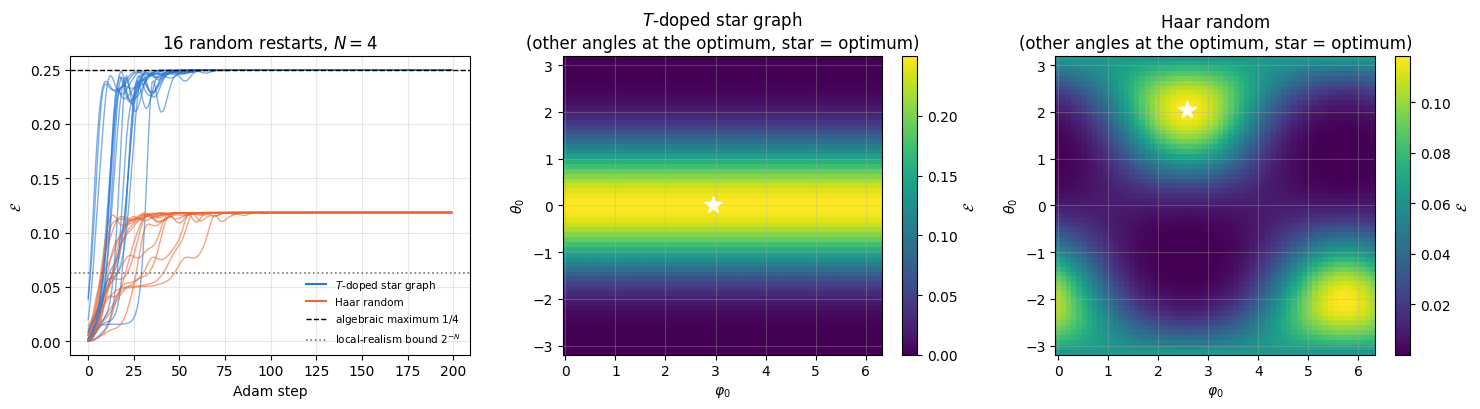

In [8]:
# ==============================================================================
# STEP 5: convergence of the restarts, and the landscape around the optimum
# ==============================================================================
# a state with a less trivial landscape: the T-doped star graph on 4 qubits
def star_graph_state(N):
    """Star graph state: |+>^N followed by CZ between qubit 0 (the hub) and every other qubit."""
    psi = product_state("+" * N)
    for q in range(1, N):
        psi = apply_gate(psi, CZ, [0, q])
    return psi


def apply_T_all(psi):
    """A T gate on every qubit -- a LOCAL unitary, so it cannot change the correlator (Eq. (16))."""
    for q in range(psi.ndim):
        psi = apply_gate(psi, T, [q])
    return psi


N_ls = 4
psi_ls = apply_T_all(star_graph_state(N_ls))                 # local-unitary image of a GHZ state
psi_hr = haar_state(jax.random.PRNGKey(17), N_ls)            # no special structure at all
a0_ls = random_angles(jax.random.PRNGKey(4), 16, N_ls)

E_ls, ang_ls, hist_ls = optimise_pure(psi_ls, a0_ls, 200, 0.1)
E_hr, ang_hr, hist_hr = optimise_pure(psi_hr, a0_ls, 200, 0.1)
hist_ls, hist_hr = np.asarray(hist_ls), np.asarray(hist_hr)
for nm, E, h in [("T-doped star graph", float(E_ls), hist_ls), ("Haar random", float(E_hr), hist_hr)]:
    print(f"{nm:>20s}: best E = {E:.8f}, Q_B = {q_values(E, N_ls)[0]:+.4f}; "
          f"final E of the 16 restarts in [{h[:, -1].min():.5f}, {h[:, -1].max():.5f}], "
          f"{int(np.sum(h[:, -1] > 0.999 * E))}/16 within 0.1% of the best")
    # first Adam step after which a restart stays within 1e-5 (relative) of its own final value
    settle = [int(np.max(np.flatnonzero(np.abs(r - r[-1]) > 1e-5 * r[-1]), initial=-1)) + 1 for r in h]
    print(f"{'':>20s}  steps to settle (median / max over restarts): {int(np.median(settle))} / {max(settle)}")

# landscapes: scan the two angles of qubit 0 with all the other angles held at the optimum
n_grid = 61
th = np.linspace(-np.pi, np.pi, n_grid)
ph = np.linspace(0, 2 * np.pi, n_grid)
TH, PH = np.meshgrid(th, ph, indexing="ij")


def landscape(psi, ang):
    def one(tt, pp):
        return correlator(psi, ang.at[0, 0].set(tt).at[0, 1].set(pp))
    return np.asarray(jax.jit(jax.vmap(jax.vmap(one)))(jnp.asarray(TH), jnp.asarray(PH)))


land_ls, land_hr = landscape(psi_ls, ang_ls), landscape(psi_hr, ang_hr)


def wrap(x, period):
    """Map an angle into [-period/2, period/2) so it can be placed on the scanned grid."""
    return (float(x) + period / 2) % period - period / 2


fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
for r in range(hist_ls.shape[0]):
    axes[0].plot(hist_ls[r], lw=1.0, color=PALETTE[0], alpha=0.6)
    axes[0].plot(hist_hr[r], lw=1.0, color=PALETTE[1], alpha=0.6)
axes[0].plot([], [], color=PALETTE[0], label=r"$T$-doped star graph")
axes[0].plot([], [], color=PALETTE[1], label="Haar random")
axes[0].axhline(0.25, color="k", ls="--", lw=1, label=r"algebraic maximum $1/4$")
axes[0].axhline(2.0 ** (-N_ls), color="0.45", ls=":", lw=1.2, label=r"local-realism bound $2^{-N}$")
axes[0].set_xlabel("Adam step"); axes[0].set_ylabel(r"$\mathcal{E}$")
axes[0].set_title(rf"16 random restarts, $N={N_ls}$"); axes[0].legend(fontsize=7.5)

for ax, land, ang, ttl in [(axes[1], land_ls, ang_ls, r"$T$-doped star graph"),
                           (axes[2], land_hr, ang_hr, "Haar random")]:
    im = ax.pcolormesh(PH, TH, land, shading="auto", cmap="viridis")
    ax.plot([wrap(ang[0, 1], 2 * np.pi) % (2 * np.pi)], [wrap(ang[0, 0], 2 * np.pi)], "w*", ms=13)
    fig.colorbar(im, ax=ax, label=r"$\mathcal{E}$")
    ax.set_xlabel(r"$\varphi_0$"); ax.set_ylabel(r"$\theta_0$")
    ax.set_title(ttl + "\n(other angles at the optimum, star = optimum)")
fig.tight_layout(); plt.show()

### 7.3 SPSA: the same maximisation without a gradient

On real hardware the correlator is estimated from counts, the exact gradient is unavailable, and one uses a stochastic
method. SPSA (Spall 1992, implemented as `spsa_grad` in the engine) perturbs *all* angles at once along a random $\pm1$
direction $\Delta$ and estimates

$$\widehat{\partial_k\mathcal E}=\frac{\mathcal E(\boldsymbol\theta+c\Delta)-\mathcal E(\boldsymbol\theta-c\Delta)}{2c}\,\Delta_k ,$$

which costs **two** evaluations regardless of $2N$. Averaged over $\Delta$ it reproduces the gradient up to a bias of order
$c^2$; a single estimate is very noisy, and Adam's momentum averages part of that noise. We run both methods from the same
starting points. A fair comparison needs each method at a step size suited to it, so SPSA is run in three settings: at the learning rate
used for the exact gradient, $0.1$, and at a five times smaller one, $0.02$; and with $1000$ instead of $200$ steps at
$0.1$, which separates "not yet converged" from "converged to the wrong place". Success is counted as ending within
$1\,\%$ of the analytic optimum, with a $95\,\%$ Wilson interval for the success fraction; timings exclude compilation,
which is measured separately.

In [9]:
# ==============================================================================
# STEP 6: gradient ascent vs SPSA from identical starting points
# ==============================================================================
@partial(jax.jit, static_argnums=(2, 3, 4))
def optimise_spsa(psi, angles0, n_steps=200, lr=0.1, c=0.05):
    """The same Adam ascent, but with the gradient replaced by an SPSA estimate (2 evaluations per step)."""
    f = lambda a: correlator(psi, a)

    def run(a0, key):
        def step(carry, k):
            a, st = carry
            g = spsa_grad(k, f, a, c=c)
            a, st = adam_update(a, -g, st, lr=lr)
            return (a, st), f(a)
        (a, _), hist = lax.scan(step, (a0, adam_init(a0)), jax.random.split(key, n_steps))
        return f(a), hist

    keys = jax.random.split(jax.random.PRNGKey(99), angles0.shape[0])
    vals, hist = jax.vmap(run)(angles0, keys)
    return vals, hist


def wilson(k, n, z=1.96):
    """95% Wilson score interval for a success fraction k/n (well behaved also at k = 0 and k = n)."""
    p, d = k / n, 1 + z * z / n
    centre, half = (p + z * z / (2 * n)) / d, z * np.sqrt(p * (1 - p) / n + z * z / (4 * n * n)) / d
    return max(0.0, centre - half), min(1.0, centre + half)


@partial(jax.jit, static_argnums=(2, 3))
def optimise_pure_final(psi, angles0, n_steps=200, lr=0.1):
    """Final E of EVERY restart of the gradient ascent of Step 4 (same Adam loop), for success statistics."""
    def run(a0):
        def step(carry, _):
            a, st = carry
            g = jax.grad(correlator, argnums=1)(psi, a)
            return adam_update(a, -g, st, lr=lr), None
        (a, _), _ = lax.scan(step, (a0, adam_init(a0)), None, length=n_steps)
        return correlator(psi, a)
    return jax.vmap(run)(angles0)


states_cmp = {"GHZ": (ghz_state(6), 0.25), "W": (w_state(6), 6 ** 2 * 4.0 ** -6),
              "Dicke m=3": (dicke_state(6, 3), comb(6, 3) ** 2 * 4.0 ** -6),
              "star graph": (star_graph_state(6), 0.25), "star + T": (apply_T_all(star_graph_state(6)), 0.25)}
R_cmp = 32
a0_cmp = random_angles(jax.random.PRNGKey(7), R_cmp, 6)
spsa_cfg = [(0.1, 200), (0.1, 1000), (0.02, 200)]          # (learning rate, steps)

# compilation, timed separately: one compile per distinct (static) setting, reused for all five states
t0 = time.time(); optimise_pure_final(ghz_state(6), a0_cmp, 200, 0.1).block_until_ready(); t_cg = time.time() - t0
t_cs = []
for lr_s, n_s in spsa_cfg:
    t0 = time.time(); optimise_spsa(ghz_state(6), a0_cmp, n_s, lr_s, 0.05)[0].block_until_ready()
    t_cs.append(time.time() - t0)
print(f"compilation + first run: grad {t_cg:.2f} s; SPSA " + ", ".join(
    f"lr={l}/{n} steps {t:.2f} s" for (l, n), t in zip(spsa_cfg, t_cs)) + "\n")

hdr = " ".join(f"{f'lr={l},{n}':>17s}" for l, n in spsa_cfg)
print(f"{'':>11s} {'grad+Adam':>12s} | SPSA best / median ({R_cmp} restarts)")
print(f"{'state':>11s} {'E':>12s} | {hdr}")
cmp_rows, succ_rows, time_rows = [], [], []
for name, (psi, E_ana) in states_cmp.items():
    t0 = time.time()
    Eg_all = np.asarray(jax.block_until_ready(optimise_pure_final(psi, a0_cmp, 200, 0.1)))
    tg = time.time() - t0
    cells, succ, times = [], [int(np.sum(Eg_all > 0.99 * E_ana))], [tg]
    for lr_s, n_s in spsa_cfg:
        t0 = time.time(); vs, _ = optimise_spsa(psi, a0_cmp, n_s, lr_s, 0.05)
        vs = np.asarray(jax.block_until_ready(vs)); times.append(time.time() - t0)
        cells.append(f"{vs.max():8.6f}/{np.median(vs):8.6f}")
        succ.append(int(np.sum(vs > 0.99 * E_ana)))
    cmp_rows.append((name, Eg_all.max(), E_ana)); succ_rows.append((name, succ)); time_rows.append((name, times))
    print(f"{name:>11s} {Eg_all.max():12.8f} | " + " ".join(f"{c:>17s}" for c in cells))
    assert abs(Eg_all.max() - E_ana) < 1e-6             # the exact gradient finds the analytic optimum

print(f"\nrestarts ending within 1% of the analytic optimum (95% Wilson interval), out of {R_cmp}")
print(f"{'state':>11s} {'grad+Adam':>17s} " + " ".join(f"{f'SPSA lr={l},{n}':>19s}" for l, n in spsa_cfg))
for name, succ in succ_rows:
    print(f"{name:>11s} " + " ".join(f"{f'{k:2d} [{wilson(k, R_cmp)[0]:.2f},{wilson(k, R_cmp)[1]:.2f}]':>19s}"
                                     for k in succ))
print(f"\nrun time after compilation [s]: " + "; ".join(
    f"{nm} " + "/".join(f"{t:.3f}" for t in ts) for nm, ts in time_rows) + "   (grad / SPSA settings in order)")

compilation + first run: grad 1.08 s; SPSA lr=0.1/200 steps 1.64 s, lr=0.1/1000 steps 1.87 s, lr=0.02/200 steps 1.45 s

               grad+Adam | SPSA best / median (32 restarts)
      state            E |        lr=0.1,200       lr=0.1,1000       lr=0.02,200


        GHZ   0.25000000 | 0.249998/0.249437 0.249983/0.248602 0.250000/0.249987


          W   0.00878906 | 0.008586/0.008051 0.008692/0.008073 0.008788/0.008763


  Dicke m=3   0.09765625 | 0.095335/0.088554 0.096951/0.087893 0.097636/0.097090


 star graph   0.25000000 | 0.244994/0.231348 0.247495/0.232089 0.249982/0.249593


   star + T   0.25000000 | 0.246322/0.222006 0.246787/0.227614 0.249983/0.249570

restarts ending within 1% of the analytic optimum (95% Wilson interval), out of 32
      state         grad+Adam     SPSA lr=0.1,200    SPSA lr=0.1,1000    SPSA lr=0.02,200
        GHZ      32 [0.89,1.00]      29 [0.76,0.97]      19 [0.42,0.74]      32 [0.89,1.00]
          W      32 [0.89,1.00]       0 [0.00,0.11]       0 [0.00,0.11]      26 [0.65,0.91]
  Dicke m=3      32 [0.89,1.00]       0 [0.00,0.11]       1 [0.01,0.16]      23 [0.55,0.84]
 star graph      32 [0.89,1.00]       0 [0.00,0.11]       0 [0.00,0.11]      28 [0.72,0.95]
   star + T      32 [0.89,1.00]       0 [0.00,0.11]       0 [0.00,0.11]      25 [0.61,0.89]

run time after compilation [s]: GHZ 0.123/0.117/0.563/0.106; W 0.097/0.112/0.606/0.107; Dicke m=3 0.091/0.111/0.646/0.086; star graph 0.102/0.105/0.639/0.106; star + T 0.100/0.113/0.566/0.138   (grad / SPSA settings in order)


### 7.4 Reading the optimisation results

For both states all $16$ restarts land on the same value to five decimals — $\mathcal E=0.25000000$ for the $T$-doped
star graph and $\mathcal E=0.11847063$ for the Haar-random state. Most of the climb happens in the first $50$–$90$
Adam steps; settling to a relative accuracy of $10^{-5}$ takes a median of about $120$ steps and at most $194$, so the
$200$-step budget is adequate but not generous. The routes differ visibly: several Haar-random restarts sit on an
intermediate plateau near $\mathcal E\approx0.05$ for tens of steps before they climb. Restarts are cheap insurance here;
they become essential once noise is added (Section 9), where a second, competing family of optima appears and six
random restarts all end up in the wrong one.

The two landscape panels explain the difference between the states. For the $T$-doped star graph, $\mathcal E$ does not
depend on $\varphi_0$ **at all**: the optimum is the whole horizontal line $\theta_0=0$. That is a property of GHZ-like
states (the hub of the star graph carries the GHZ frame, and $T$ commutes with $R_z$), and it follows from Eq. (12) — for
the GHZ state at $\theta_k=0$ the two array entries are
$\psi'[0\ldots0]=\tfrac{1}{\sqrt2}\prod_ke^{i\varphi_k/2}$ and $\psi'[1\ldots1]=\tfrac{1}{\sqrt2}\prod_ke^{-i\varphi_k/2}$,
so every $\varphi_k$ cancels in the modulus. The optimum is a continuous $N$-dimensional manifold, the Hessian is singular
along it, and any gradient method slides freely along the ridge until it stops at an arbitrary point of it. The
Haar-random state has no such symmetry: its slice shows two isolated peaks separated by regions where $\mathcal E$ falls
to zero. The two peaks are one and the same maximum. The chart $(\theta,\varphi)$ covers every measurement frame twice:
since $R_y(-\theta)=ZR_y(\theta)Z$ and $R_z(\pi)=-iZ$, one has $R_z(\varphi+\pi)R_y(-\theta)=-i\,R_z(\varphi)R_y(\theta)Z$, and
$Z\sigma^{-}Z=-\sigma^{-}$, so $(\theta_0,\varphi_0)\to(-\theta_0,\varphi_0+\pi)$ only flips the sign of
$\tilde\sigma^{-}_0$ (both outcomes of $A_0$ and of $B_0$ relabelled) and leaves $\mathcal E$ unchanged.

In the method comparison, gradient ascent reaches the analytic optimum from all $32$ starting points for every state:
$0.25$ for GHZ, the star graph and the $T$-doped star graph, $0.09765625=\binom{6}{3}^24^{-6}$ for the Dicke state and
$0.00878906=6^2\cdot4^{-6}$ for W. SPSA run with the same learning rate, $0.1$, reproduces GHZ to five digits but falls
short of the other four optima by $1.5$–$2.4\,\%$ even in its best restart, and *no* restart of those four ends within
$1\,\%$ of the optimum (0 of 32, Wilson interval $[0,0.11]$). Five times as many steps do not repair this: at
$1000$ steps the medians are essentially unchanged and the GHZ success count even drops from $29$ to $19$. At the smaller
learning rate $0.02$ and the original $200$ steps, $23$–$28$ of the $32$ restarts succeed for those four states and all
$32$ for GHZ. The shortfall is therefore set by the step size and does not shrink with the number of steps. A mechanism
consistent with this: with exact function values
the SPSA estimate $\Delta(\Delta\cdot\nabla\mathcal E)+O(c^2)$ vanishes at a stationary point, so its noise is
proportional to the gradient; but Adam divides every component by the running root-mean-square of the estimates, so
near the optimum the steps keep a length of order the learning rate in directions that are mostly random. The iterate
then wanders in a region around the optimum whose size is set by the learning rate. Exercise 4 asks you to shrink that
region with a decaying learning rate. In this simulator the exact gradient is essentially free: after compilation every
run of $32$ restarts at $200$ steps takes less than $0.15$ s for either method (last output line), so `jax.grad` wins on
accuracy at equal cost.
On hardware, where each evaluation costs thousands of shots and no gradient is available, the ranking reverses; that is the
regime [notebook 41](../ch11_variational_quantum_circuits/41_optimizers.ipynb) analyses.

## 8. The test states

Now the full list: the product state, GHZ in the computational basis, GHZ written in randomly rotated local bases, the star
graph state, the star graph with a $T$ gate on every qubit, the W state, the Dicke state at half filling, the linear cluster
state and a Haar-random state. Every value is obtained by free optimisation over all $2N$ angles, so the analytic formulas
of Section 6 are now genuine predictions and not just evaluations at a guessed point.

In [10]:
# ==============================================================================
# STEP 7: the zoo, optimised over all 2N angles
# ==============================================================================
def ghz_random_bases(key, N):
    """GHZ written in a random local basis on every qubit: 1 (Z basis), H (X basis) or S H (H first, then S: Y basis).
    By Eq. (16) this MUST give the same correlator as the plain GHZ state."""
    psi = ghz_state(N)
    codes = jax.random.randint(key, (N,), 0, 3)
    for q in range(N):
        c = int(codes[q])
        if c == 1:
            psi = apply_gate(psi, H, [q])
        elif c == 2:
            psi = apply_gate(psi, S @ H, [q])          # |0> -> |+i>, |1> -> |-i>
    return psi, "".join("ZXY"[int(c)] for c in codes)


def linear_cluster(N):
    """1D cluster state: |+>^N with CZ on every nearest-neighbour bond."""
    psi = product_state("+" * N)
    for q in range(N - 1):
        psi = apply_gate(psi, CZ, [q, q + 1])
    return psi


rows = []
for N in (4, 6):
    psi_gr, bases = ghz_random_bases(jax.random.PRNGKey(20 + N), N)
    zoo = {"product |+>^N": product_state("+" * N),
           "GHZ (Z basis)": ghz_state(N),
           f"GHZ (bases {bases})": psi_gr,
           "star graph": star_graph_state(N),
           "star graph + T": apply_T_all(star_graph_state(N)),
           "W": w_state(N),
           "Dicke m = N/2": dicke_state(N, N // 2),
           "linear cluster": linear_cluster(N),
           "Haar random": haar_state(jax.random.PRNGKey(5), N)}
    a0 = random_angles(jax.random.PRNGKey(31 + N), 24, N)
    print(f"\n=== N = {N} ===  (24 restarts x 250 Adam steps; bounds: Q_B <= {N-2}, Q_E <= {N-1})")
    print(f"{'state':>26s} {'E':>12s} {'Q_B':>9s} {'Q_E':>9s}  verdict")
    for name, psi in zoo.items():
        E = float(optimise_pure(psi, a0, 250, 0.1)[0])
        qb, qe = q_values(E, N)
        MARGIN = 1e-4          # require a strict violation, not a value sitting exactly on the bound
        verdict = ("Bell-correlated" if qb > MARGIN else ("entangled" if qe > MARGIN else "no certificate"))
        if qb > N - 4 + MARGIN:
            verdict += ", genuinely N-partite"
        rows.append((N, name, E, qb, qe))
        print(f"{name:>26s} {E:12.6e} {qb:+9.4f} {qe:+9.4f}  {verdict}")


=== N = 4 ===  (24 restarts x 250 Adam steps; bounds: Q_B <= 2, Q_E <= 3)
                     state            E       Q_B       Q_E  verdict


             product |+>^N 3.906250e-03   -4.0000   -0.0000  no certificate
             GHZ (Z basis) 2.500000e-01   +2.0000   +3.0000  Bell-correlated, genuinely N-partite
          GHZ (bases ZZYY) 2.500000e-01   +2.0000   +3.0000  Bell-correlated, genuinely N-partite
                star graph 2.500000e-01   +2.0000   +3.0000  Bell-correlated, genuinely N-partite
            star graph + T 2.500000e-01   +2.0000   +3.0000  Bell-correlated, genuinely N-partite


                         W 6.250000e-02   -0.0000   +2.0000  entangled
             Dicke m = N/2 1.406250e-01   +1.1699   +2.5850  Bell-correlated, genuinely N-partite
            linear cluster 6.250000e-02   -0.0000   +2.0000  entangled
               Haar random 5.300799e-02   -0.2376   +1.8812  entangled



=== N = 6 ===  (24 restarts x 250 Adam steps; bounds: Q_B <= 4, Q_E <= 5)
                     state            E       Q_B       Q_E  verdict


             product |+>^N 2.441406e-04   -6.0000   -0.0000  no certificate
             GHZ (Z basis) 2.500000e-01   +4.0000   +5.0000  Bell-correlated, genuinely N-partite


        GHZ (bases YYXZXY) 2.500000e-01   +4.0000   +5.0000  Bell-correlated, genuinely N-partite
                star graph 2.500000e-01   +4.0000   +5.0000  Bell-correlated, genuinely N-partite


            star graph + T 2.500000e-01   +4.0000   +5.0000  Bell-correlated, genuinely N-partite
                         W 8.789062e-03   -0.8301   +2.5850  entangled
             Dicke m = N/2 9.765625e-02   +2.6439   +4.3219  Bell-correlated, genuinely N-partite


            linear cluster 1.562500e-02   -0.0000   +3.0000  entangled
               Haar random 1.565121e-02   +0.0024   +3.0012  Bell-correlated


### 8.1 Two entries that need more than one size and more than one sample

The two rows that do not follow from Sections 4 and 6 — the linear cluster state and the Haar-random state — are exactly
the two for which a single number at a single $N$ proves nothing. The cluster state lands on $\mathcal E=2^{-N}$ at
$N=4$ and $N=6$; whether that is a rule or a coincidence of two sizes can only be decided by scanning $N$. The
Haar-random entry is one draw from a distribution; whether the sign of its $Q_{\rm B}$ is typical can only be decided by
drawing more. We do both.

In [11]:
# ==============================================================================
# STEP 7b: the linear cluster state as a function of N, and the Haar ENSEMBLE
# ==============================================================================
@partial(jax.jit, static_argnums=(2, 3))
def optimise_many(psis, angles0, n_steps=200, lr=0.1):
    """Optimise a BATCH of pure states at once.  psis: (S,2,..,2), angles0: (S,R,N,2) -> best E per state.
    JAX: vmap over states (outer) and over restarts (inner); one compilation for the whole ensemble."""
    def one(psi, a_restarts):
        def run(a0):
            def step(carry, _):
                a, st = carry
                val, g = jax.value_and_grad(correlator, argnums=1)(psi, a)
                a, st = adam_update(a, -g, st, lr=lr)
                return (a, st), val
            (a, _), _ = lax.scan(step, (a0, adam_init(a0)), None, length=n_steps)
            return correlator(psi, a)
        return jnp.max(jax.vmap(run)(a_restarts))
    return jax.vmap(one)(psis, angles0)


print("linear cluster state, free optimisation over all 2N angles")
print(f"{'N':>2s} {'E':>13s} {'2^-N':>13s} {'Q_B':>8s} {'gamma = -log4(E)-1':>20s}")
for N in range(3, 9):
    E = float(optimise_pure(linear_cluster(N), random_angles(jax.random.PRNGKey(41), 24, N), 250, 0.1)[0])
    gam = -np.log(E) / np.log(4.0) - 1.0
    print(f"{N:2d} {E:13.6e} {2.0**(-N):13.6e} {q_values(E, N)[0]:+8.4f} {gam:20.4f}")

S_h, R_h, n_h = 32, 16, 400
print(f"\nHaar-random states: {S_h} independent draws at each N; {R_h} restarts x {n_h} Adam steps, run twice with")
print("independent starting angles (the larger of the two runs is kept; 'max |dQ|' measures convergence)")
print(f"{'N':>2s} {'mean Q_B':>9s} {'s.e.':>7s} {'median':>8s} {'min':>8s} {'max':>8s} {'Q_B > 0':>8s} "
      f"{'95% Wilson':>13s} {'max |dQ|':>9s}")
haar_stats = {}
for N in (4, 6, 8):
    psis = jnp.stack([haar_state(jax.random.PRNGKey(2000 + s), N) for s in range(S_h)])
    runs = [q_values(np.asarray(optimise_many(psis, random_angles(jax.random.PRNGKey(9 + r), S_h * R_h, N)
                                              .reshape(S_h, R_h, N, 2), n_h, 0.1)), N)[0] for r in (0, 1)]
    qb_h, dq = np.maximum(runs[0], runs[1]), float(np.max(np.abs(runs[0] - runs[1])))
    k_h = int(np.sum(qb_h > 0)); lo_h, hi_h = wilson(k_h, S_h)
    haar_stats[N] = qb_h
    print(f"{N:2d} {qb_h.mean():+9.4f} {qb_h.std(ddof=1) / np.sqrt(S_h):7.4f} {np.median(qb_h):+8.4f} "
          f"{qb_h.min():+8.4f} {qb_h.max():+8.4f} {k_h:4d}/{S_h} {f'[{lo_h:.2f}, {hi_h:.2f}]':>13s} {dq:9.1e}")
    assert dq < 1e-2                     # the two independent optimisations agree: the ensemble is converged

linear cluster state, free optimisation over all 2N angles
 N             E          2^-N      Q_B   gamma = -log4(E)-1


 3  2.500000e-01  1.250000e-01  +1.0000               0.0000
 4  6.250000e-02  6.250000e-02  -0.0000               1.0000


 5  1.562500e-02  3.125000e-02  -1.0000               2.0000
 6  1.562500e-02  1.562500e-02  -0.0000               2.0000


 7  3.906250e-03  7.812500e-03  -1.0000               3.0000


 8  9.765625e-04  3.906250e-03  -2.0000               4.0000

Haar-random states: 32 independent draws at each N; 16 restarts x 400 Adam steps, run twice with
independent starting angles (the larger of the two runs is kept; 'max |dQ|' measures convergence)
 N  mean Q_B    s.e.   median      min      max  Q_B > 0    95% Wilson  max |dQ|


 4   +0.2624  0.0771  +0.3003  -0.7170  +1.0249   23/32  [0.55, 0.84]   1.8e-15


 6   -0.1372  0.0512  -0.1640  -0.6905  +0.3817    9/32  [0.16, 0.45]   1.8e-15


 8   -0.8166  0.0438  -0.8235  -1.2828  -0.3197    0/32  [0.00, 0.11]   2.5e-04


Neither entry survives the extra evidence in the form in which the table presents it.

The cluster state does **not** obey $\mathcal E=2^{-N}$ in general. Writing $\mathcal E=4^{-(1+\gamma)}$, the measured
exponent is $\gamma=0,1,2,2,3,4$ for $N=3,\dots,8$, i.e. $\gamma=\lfloor 2(N-2)/3\rfloor$ over this range, so
$Q_{\rm B}=N-2-2\lfloor2(N-2)/3\rfloor$ takes the values $+1,0,-1,0,-1,-2$. The three-qubit chain is a GHZ state in
disguise and violates the bound; $N=4$ and $N=6$ are the only two sizes in the range that land exactly *on* it; from
there $Q_{\rm B}$ drifts down by roughly one unit per three qubits. A one-dimensional cluster state is therefore a
textbook example of a state that is maximally useful for measurement-based computation and useless for this correlator,
and the agreement with $2^{-N}$ at $N=4,6$ is a coincidence of those two sizes. (No proof of the $\lfloor
2(N-2)/3\rfloor$ pattern is offered here; it is an observation over $3\le N\le8$.)

The Haar-random entry is even more misleading as a single number. Over $32$ draws per size the *typical* $Q_{\rm B}$
**falls** with $N$: the mean is $+0.26\pm0.08$ at $N=4$, $-0.14\pm0.05$ at $N=6$ and $-0.82\pm0.04$ at $N=8$ (standard
errors), and the number of draws that violate the local-realism bound goes $23\to9\to0$ out of $32$, with $95\,\%$
Wilson intervals $[0.55,0.84]$, $[0.16,0.45]$ and $[0,0.11]$ for the fraction, which do not overlap. The two independent
optimisations of every draw agree to $2.5\cdot10^{-4}$ in $Q_{\rm B}$, so these are properties of the states and not of
the optimiser (with only $8$ restarts of $200$ steps, single draws at $N=8$ came out up to $0.13$ too low). The single seed quoted in the
table above happens to be in the lower tail at $N=4$ and slightly above the median at $N=6$, which produces exactly the
opposite impression — that random states become
*more* nonlocal with $N$. They do not: as $N$ grows, a Haar-random state spreads its weight over all $2^N$ basis states
and the single coherence $\langle0\cdots0\vert\rho\vert1\cdots1\rangle$ that this correlator measures shrinks faster
than the bound it has to beat.

> **Numerical practice.** One state at one size is an anecdote. Before writing "the correlator is positive for random
> states", sample the ensemble and quote a distribution; before writing "$\mathcal E=2^{-N}$ for cluster states", scan
> $N$. Both of these took a few seconds here and both changed the conclusion.

### 8.2 What the table says

Read it against Sections 4 and 6.

* $\vert+\rangle^{\otimes N}$ lands on $Q_{\rm E}=0$ to six decimals: the optimiser cannot push a product state above the
  separability bound, which is the strongest available check that the code and the bound are consistent.
* GHZ in the computational basis, GHZ in randomly rotated bases, the star graph and the $T$-doped star graph all give the
  **same** $\mathcal E=1/4$ and $Q_{\rm B}=N-2$. That is Eq. (16) at work: all four are related by local unitaries, and the
  correlator cannot see the difference. In particular the $T$ gates, which make the state non-stabilizer and give it
  non-zero magic, are invisible here.
* All four exceed $N-4$, so each is certified genuinely $N$-partite entangled by the $m=2$ case of Eq. (10).
* W and Dicke reproduce Eq. (15) exactly: free optimisation over all $2N$ angles from $24$ random starts finds nothing
  better than the symmetric single-angle ansatz of Section 6.3, which is strong numerical evidence that it is the global
  optimum.
* The linear cluster state and the Haar-random state are the interesting cases. Both are strongly entangled — the cluster
  state is the universal resource for measurement-based computation, the random state has volume-law entropy — yet the
  correlator barely notices. The linear cluster state lands on $\mathcal E=2^{-N}$ at both of these sizes
  ($0.0625=2^{-4}$ and $0.015625=2^{-6}$), i.e. $Q_{\rm B}=0.0000$: it sits precisely on the local-realism bound and
  violates nothing — and Section 8.1 showed that this is an accident of $N=4,6$, with $Q_{\rm B}$ falling steadily at
  larger $N$. The Haar-random draws give $Q_{\rm B}=-0.2376$ at $N=4$ and $Q_{\rm B}=+0.0024$ at $N=6$ — a violation
  so marginal that it would be invisible in any experiment, and, as the ensemble of Section 8.1 shows, not
  representative: the typical $Q_{\rm B}$ of a Haar state decreases with $N$. This correlator is built around a single $N$-body coherence
  $\langle0\cdots0\vert\rho\vert1\cdots1\rangle$ and is therefore tuned to GHZ-like states; entanglement spread over many
  patterns does not show up in it. A non-positive $Q_{\rm B}$ is **not** evidence of a separable state: Bell inequalities
  are one-sided certificates.

> **Physics insight.** A diagnostic that answers "yes" loudly for GHZ and "no" for a Haar-random state is working as
> designed: *Bell correlations of this type* are a specific structure, a single $N$-body coherence in some local frame,
> and a large amount of entanglement does not imply it. Notebook 25 measures a quantity (the negativity) that ranks the random state far above GHZ; the two
> diagnostics see genuinely different things.

## 9. Noise on the density tensor

### 9.1 Closed forms at the identity angles

Apply a single-qubit channel to every qubit of the GHZ state. At the identity angles, Eq. (13) says that
$\langle\mathcal B\rangle$ is simply the corner element $\rho_{0\cdots0,\,1\cdots1}$ — the $N$-body coherence whose decay
[notebook 22](../ch08_quantum_information_protocols/22_ghz_states_and_decoherence.ipynb) studies through parity
oscillations. Each channel multiplies it by a fixed factor per qubit:

* **dephasing** with probability $p$ maps $\rho_{01}\to(1-2p)\rho_{01}$ on each qubit, so the corner element picks up
  $(1-2p)^N$ and

  $$\mathcal E_{\rm deph}(p)=\tfrac14(1-2p)^{2N} ;$$

* **depolarising** with probability $p$ shrinks the Bloch vector by $\eta=1-\tfrac43p$, hence also every off-diagonal
  single-qubit matrix element, and

  $$\mathcal E_{\rm depol}(p)=\tfrac14\,\eta^{2N},\qquad\eta=1-\tfrac43p ;$$

* **amplitude damping** with probability $\gamma$ has $K_0=\mathrm{diag}(1,\sqrt{1-\gamma})$ and
  $K_1=\sqrt\gamma\vert0\rangle\langle1\vert$. In $\langle0^N\vert K_m\rho K_m^{\dagger}\vert1^N\rangle$ only the branch
  $m=0$ survives on every qubit ($K_1^{\dagger}\vert1\rangle=0$), contributing $1\cdot\sqrt{1-\gamma}$ per site, so

  $$\mathcal E_{\rm AD}(\gamma)=\tfrac14(1-\gamma)^{N} .$$

These are values at *fixed* angles, hence lower bounds on $\mathcal E$. Whether they are the maximum is a question for the
optimiser, and Section 9.3 shows that they stop being the maximum once the noise is strong.

### 9.2 Critical noise

Setting $Q_{\rm B}=0$ (i.e. $\mathcal E=2^{-N}$) and $Q_{\rm E}=0$ (i.e. $\mathcal E=4^{-N}$) in the dephasing formula gives

$$1-2p_{\rm B}=2^{\frac{2-N}{2N}},\qquad 1-2p_{\rm E}=2^{\frac{1}{N}-1} , \tag{17}$$

and the same two equations with $1-2p$ replaced by $\eta=1-\tfrac43p$ for depolarising, or by $(1-\gamma)^{1/2}$ for
amplitude damping. Both exponents have finite limits: $\tfrac{2-N}{2N}=\tfrac1N-\tfrac12\to-\tfrac12$ and
$\tfrac1N-1\to-1$, so

$$p_{\rm B}\longrightarrow\tfrac12\bigl(1-2^{-1/2}\bigr)=0.1464,\qquad
  p_{\rm E}\longrightarrow\tfrac12\bigl(1-2^{-1}\bigr)=0.25 .$$

Two facts follow. First, the Bell threshold is always *below* the entanglement threshold — at every $N$ there is a window of noise in which
the state is still certified entangled but no longer certified nonlocal. Second, the per-qubit noise tolerance does **not**
shrink with $N$: it *grows*, from $p_{\rm B}=0.0546$ at $N=3$ towards the asymptote $0.1464$. The reason is that the
local-realism bound $2^{-N}$ shrinks exponentially too, and for this particular correlator the two exponentials nearly
cancel. What does get harder with $N$ is the *total* amount of noise $Np$ that the experiment must keep under control, and
the preparation of the state itself.

One limitation of Eq. (17) has to be stated now, because it is invisible in the algebra: the equation is solved for the
*identity-angle* value of $\mathcal E$, so it locates the crossing of the closed form, not of the maximised correlator.
Section 9.3 shows that for dephasing the two part company at $p\approx0.19$ for $N=4$. The Bell thresholds $p_{\rm B}$ all lie
below that crossover and are therefore genuine. The entanglement thresholds $p_{\rm E}$ do not: for even $N$ the
maximised correlator under dephasing approaches $4^{-N}$ from *above* and never crosses it, so $Q_{\rm E}$ stays
non-negative at every $p$ and the entanglement certificate is not lost at all. The $p_{\rm E}$ column is therefore the
noise at which the *coherence branch* falls to the separability bound; for even $N$ the certificate itself survives it.

In [12]:
# ==============================================================================
# STEP 8: the three channels on the GHZ state, at the identity angles, N = 6
# ==============================================================================
def noisy_ghz_dm(N, kraus):
    """rho = channel^{(x)N} ( |GHZ><GHZ| ) as a density tensor: one Kraus channel per qubit."""
    rho = to_dm(ghz_state(N))
    for q in range(N):
        rho = apply_kraus_dm(rho, kraus, [q])
    return rho


N_dm = 6
print(f"N = {N_dm}, identity angles; 'analytic' from Section 9.1")
print(f"{'p':>5s} | {'dephasing':>23s} | {'depolarising':>23s} | {'amp. damping':>23s}")
print(f"{'':>5s} | {'E':>11s} {'analytic':>11s} | {'E':>11s} {'analytic':>11s} | {'E':>11s} {'analytic':>11s}")
worst = 0.0
for p in (0.0, 0.05, 0.10, 0.15, 0.20):
    e_de = float(correlator_dm(noisy_ghz_dm(N_dm, kraus_dephasing(p)), zero_angles(N_dm)))
    e_dp = float(correlator_dm(noisy_ghz_dm(N_dm, kraus_depolarizing(p)), zero_angles(N_dm)))
    e_ad = float(correlator_dm(noisy_ghz_dm(N_dm, kraus_amplitude_damping(p)), zero_angles(N_dm)))
    a_de = 0.25 * (1 - 2 * p) ** (2 * N_dm)
    a_dp = 0.25 * (1 - 4 * p / 3) ** (2 * N_dm)
    a_ad = 0.25 * (1 - p) ** N_dm
    worst = max(worst, abs(e_de - a_de), abs(e_dp - a_dp), abs(e_ad - a_ad))
    print(f"{p:5.2f} | {e_de:11.4e} {a_de:11.4e} | {e_dp:11.4e} {a_dp:11.4e} | {e_ad:11.4e} {a_ad:11.4e}")
print(f"\nlargest deviation from the closed forms: {worst:.2e}")
assert worst < 1e3 * TOL

N = 6, identity angles; 'analytic' from Section 9.1
    p |               dephasing |            depolarising |            amp. damping
      |           E    analytic |           E    analytic |           E    analytic


 0.00 |  2.5000e-01  2.5000e-01 |  2.5000e-01  2.5000e-01 |  2.5000e-01  2.5000e-01
 0.05 |  7.0607e-02  7.0607e-02 |  1.0924e-01  1.0924e-01 |  1.8377e-01  1.8377e-01
 0.10 |  1.7180e-02  1.7180e-02 |  4.4892e-02  4.4892e-02 |  1.3286e-01  1.3286e-01
 0.15 |  3.4603e-03  3.4603e-03 |  1.7180e-02  1.7180e-02 |  9.4287e-02  9.4287e-02


 0.20 |  5.4420e-04  5.4420e-04 |  6.0472e-03  6.0472e-03 |  6.5536e-02  6.5536e-02

largest deviation from the closed forms: 3.61e-16


### 9.3 Full optimisation under noise

Now let the optimiser choose the angles at every noise strength. Two things can happen: it confirms the closed form, or it
finds something better. A density tensor is $4^N$ complex numbers and every one of the thousands of optimiser evaluations
applies $2N$ gates to all of them, so the cost grows as $4^N$ and we run the full sweep at $N=4$, batching the whole noise
grid and all restarts into a single `vmap` (the closed forms themselves were already verified at $N=6$ in Step 8).

Two of the restarts are not random. Whenever an achievable value of the objective is known in closed form, the angles
that achieve it belong in the starting batch: here that is the identity angles of Section 9.1 and the symmetric choice
$\theta_k=\pi/2$ of Section 6.3. With those two included the returned maximum can never be *smaller* than the closed
form, which turns the comparison "optimised versus analytic" into a one-sided test with a known sign — and lets us
`assert` it. With six purely random restarts and $150$ steps the sweep does fail that test near $p=0.15$: every restart
is then attracted to the $\theta=\pi/2$ branch discussed below, which at that noise strength is a *local* maximum lying
a factor of $2.4$ below the global one.

three noise sweeps, N = 4, 10 points x (2 seeded + 6 random) restarts x 150 steps: 4.2 s

    p |                   dephasing |                depolarising |           amplitude damping
      |   E optimised    E identity |   E optimised    E identity |   E optimised    E identity
 0.00 |   2.50000e-01   2.50000e-01 |   2.50000e-01   2.50000e-01 |   2.50000e-01   2.50000e-01
 0.05 |   1.07617e-01   1.07617e-01 |   1.43957e-01   1.43957e-01 |   2.03627e-01   2.03627e-01
 0.10 |   4.19430e-02   4.19430e-02 |   7.95714e-02   7.95714e-02 |   1.64025e-01   1.64025e-01
 0.15 |   1.44120e-02   1.44120e-02 |   4.19430e-02   4.19430e-02 |   1.30502e-01   1.30502e-01
 0.20 |   4.98436e-03   4.19904e-03 |   2.09099e-02   2.09099e-02 |   1.02400e-01   1.02400e-01
 0.25 |   4.40979e-03   9.76562e-04 |   9.75461e-03   9.75461e-03 |   7.91016e-02   7.91016e-02
 0.30 |   4.10881e-03   1.63840e-04 |   4.19904e-03   4.19904e-03 |   6.00250e-02   6.00250e-02
 0.35 |   3.96979e-03   1.64025e-05 |   1.6365

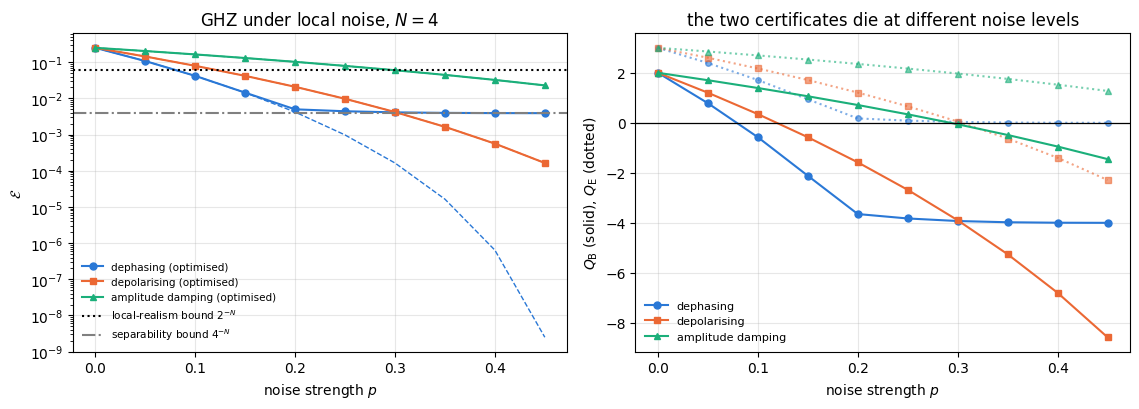

In [13]:
# ==============================================================================
# STEP 9: optimised correlator vs noise, density tensor
# ==============================================================================
@partial(jax.jit, static_argnums=(2,))
def optimise_dm_batch(rhos, angles0, n_steps=150, lr=0.1):
    """Optimise the angles for a BATCH of density tensors at once.
    rhos: (P, 2,...,2) of rank 1+2N ; angles0: (P, R, N, 2).  Returns the best E for each of the P states.
    JAX: vmap over the noise grid (outer) and over the restarts (inner); one compilation for the whole sweep."""
    def one(rho, a_restarts):
        def run(a0):
            def step(carry, _):
                a, st = carry
                val, g = jax.value_and_grad(correlator_dm, argnums=1)(rho, a)
                a, st = adam_update(a, -g, st, lr=lr)
                return (a, st), val
            (a, _), _ = lax.scan(step, (a0, adam_init(a0)), None, length=n_steps)
            return correlator_dm(rho, a)
        return jnp.max(jax.vmap(run)(a_restarts))
    return jax.vmap(one)(rhos, angles0)


N_ns = 4                      # small enough that the whole sweep fits in one batched optimisation
p_grid = np.linspace(0.0, 0.45, 10)
channels = {"dephasing": (kraus_dephasing, lambda p: 0.25 * (1 - 2 * p) ** (2 * N_ns)),
            "depolarising": (kraus_depolarizing, lambda p: 0.25 * (1 - 4 * p / 3) ** (2 * N_ns)),
            "amplitude damping": (kraus_amplitude_damping, lambda p: 0.25 * (1 - p) ** N_ns)}

def seeded_restarts(key, n_random, N, n_points):
    """Restart batch of shape (n_points, 2 + n_random, N, 2): the two ANALYTIC candidates of Section 6
    (all angles zero, and theta = pi/2 everywhere) followed by `n_random` uniform starts.
    Seeding the batch with angles whose value we already know guarantees that the optimiser can never
    return less than the closed form -- see the checkpoint below."""
    fixed = jnp.stack([zero_angles(N), sym_angles(N)])                       # (2, N, 2)
    fixed = jnp.tile(fixed[None], (n_points, 1, 1, 1))                       # (P, 2, N, 2)
    rnd = random_angles(key, n_random * n_points, N).reshape(n_points, n_random, N, 2)
    return jnp.concatenate([fixed, rnd], axis=1)


t0 = time.time()
results_ns = {}
for ci, (cname, (kr, ana)) in enumerate(channels.items()):
    rhos = jnp.stack([noisy_ghz_dm(N_ns, kr(float(p))) for p in p_grid])
    a0 = seeded_restarts(jax.random.PRNGKey(300 + ci), 6, N_ns, len(p_grid))
    E_opt = np.asarray(optimise_dm_batch(rhos, a0, 150, 0.1))
    E_id = np.array([ana(p) for p in p_grid])
    # CHECKPOINT: a maximum can never be smaller than a value we can write down
    assert np.all(E_opt >= E_id - 1e3 * TOL), f"{cname}: optimiser fell below the closed form"
    results_ns[cname] = (E_opt, E_id)
print(f"three noise sweeps, N = {N_ns}, 10 points x (2 seeded + 6 random) restarts x 150 steps: "
      f"{time.time()-t0:.1f} s\n")

print(f"{'p':>5s} | " + " | ".join(f"{c:>27s}" for c in channels))
print(f"{'':>5s} | " + " | ".join(f"{'E optimised':>13s} {'E identity':>13s}" for _ in channels))
for i, p in enumerate(p_grid):
    line = f"{p:5.2f} | "
    line += " | ".join(f"{results_ns[c][0][i]:13.5e} {results_ns[c][1][i]:13.5e}" for c in channels)
    print(line)

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2))
for j, c in enumerate(channels):
    E_opt, E_id = results_ns[c]
    axes[0].semilogy(p_grid, E_opt, MARKERS[j] + "-", ms=5, color=PALETTE[j], label=c + " (optimised)")
    axes[0].semilogy(p_grid, E_id, "--", lw=1, color=PALETTE[j])
axes[0].axhline(2.0 ** (-N_ns), color="k", ls=":", label=r"local-realism bound $2^{-N}$")
axes[0].axhline(4.0 ** (-N_ns), color="0.5", ls="-.", label=r"separability bound $4^{-N}$")
axes[0].set_xlabel(r"noise strength $p$"); axes[0].set_ylabel(r"$\mathcal{E}$")
axes[0].set_title(rf"GHZ under local noise, $N={N_ns}$"); axes[0].legend(fontsize=7.5)

for j, c in enumerate(channels):
    qb, qe = q_values(results_ns[c][0], N_ns)
    axes[1].plot(p_grid, qb, MARKERS[j] + "-", ms=5, color=PALETTE[j], label=c)
    axes[1].plot(p_grid, qe, MARKERS[j] + ":", ms=4, color=PALETTE[j], alpha=0.6)
axes[1].axhline(0, color="k", lw=0.9)
axes[1].set_xlabel(r"noise strength $p$"); axes[1].set_ylabel(r"$Q_{\rm B}$ (solid), $Q_{\rm E}$ (dotted)")
axes[1].set_title("the two certificates die at different noise levels"); axes[1].legend(fontsize=8)
fig.tight_layout(); plt.show()

For **depolarising** noise and **amplitude damping** the optimiser reproduces the closed form of Section 9.1 at every point
of the grid, to all printed digits: the identity angles stay optimal however strong the noise. For **dephasing** they do
not. From $p=0.20$ onward the optimised value overtakes the closed form and settles on a plateau just above
$\mathcal E=3.907\cdot10^{-3}$, while the coherence formula keeps falling and reaches $2.5\cdot10^{-9}$ at $p=0.45$.

The second branch can be written down exactly. Local dephasing leaves the GHZ state in the form

$$\rho(p)=\tfrac12\bigl(\vert0^N\rangle\langle0^N\vert+\vert1^N\rangle\langle1^N\vert\bigr)
  +\tfrac{c^{N}}{2}\bigl(\vert0^N\rangle\langle1^N\vert+\vert1^N\rangle\langle0^N\vert\bigr),\qquad c=1-2p ,$$

and evaluating Eq. (13) on it with $U_k=R_z(\varphi_k)R_y(\theta_k)$, writing $c_k=\cos\tfrac{\theta_k}{2}$ and
$s_k=\sin\tfrac{\theta_k}{2}$, gives

$$\rho'[0\ldots0;1\ldots1]=\tfrac{1+(-1)^N}{2}\prod_k c_ks_k
  +\tfrac{c^{N}}{2}\Bigl[\prod_kc_k^2\,e^{i\Phi}+(-1)^N\prod_ks_k^2\,e^{-i\Phi}\Bigr],\qquad\Phi=\sum_k\varphi_k .$$

The first term is the classical mixture $\tfrac12(\vert0^N\rangle\langle0^N\vert+\vert1^N\rangle\langle1^N\vert)$ that
survives at $p=\tfrac12$; the second is the surviving coherence. For **even** $N$, $\theta_k=\pi/2$ and $\Phi=0$ make
both terms real and positive, and

$$\mathcal E_{\theta=\pi/2}(p)=4^{-N}\bigl(1+c^{N}\bigr)^2 .$$

At $p=\tfrac12$ this is exactly $4^{-N}$ — the separability bound, saturated but never exceeded by the (separable)
classical mixture, as Eq. (10) requires; at smaller $p$ it sits slightly above it. (For odd $N$ the first term cancels
and the classical mixture gives $\mathcal E=0$; Exercise 7 asks you to check this.) So for even $N$ the optimum is the
larger of two branches,

$$\mathcal E_{\rm opt}(p)=\max\Bigl[\tfrac14c^{2N},\;4^{-N}(1+c^{N})^2\Bigr] ,$$

which reproduces the measured column to all printed digits. The two branches cross where
$c^{N}=1/(2^{N-1}-1)$, i.e. at $p=0.1926$ for $N=4$ (and $0.2179$ at $N=6$, $0.2271$ at $N=8$): *that* is where the
optimal measurement directions jump from $\theta=0$ to $\theta=\pi/2$, not at $p=0.15$ where the two curves in the
figure already look close. Depolarising and amplitude damping have no such second branch because they drive the state
towards $\mathbb 1/2^N$ and $\vert0\cdots0\rangle$ respectively, and both of those have $\mathcal E=0$.

> **Common pitfall.** A closed form derived at one fixed choice of settings is a *lower* bound on a maximised quantity,
> never the answer — and a numerical maximum is a lower bound too. The two failure modes point in opposite directions
> and you need both guards: let the optimiser check the formula (here it is exact over the whole range for two of the
> three channels and wrong by five orders of magnitude for the third), and let the formula check the optimiser (put the
> known angles into the restart batch and `assert` that the returned maximum is at least the closed form).

### 9.4 Critical noise as a function of $N$

Solving Eq. (17) gives the noise strength at which each certificate is lost. We compare those closed forms with the noise
grid just measured, and then evaluate them for larger $N$ where the density tensor would be too expensive.

  N |         dephasing |      depolarising |      amp. damping
    |      p_B      p_E |      p_B      p_E |      g_B      g_E
  3 |   0.0546   0.1850 |   0.0818   0.2775 |   0.2063   0.6031
  4 |   0.0796   0.2027 |   0.1193   0.3040 |   0.2929   0.6464
  6 |   0.1031   0.2194 |   0.1547   0.3291 |   0.3700   0.6850
  8 |   0.1144   0.2274 |   0.1717   0.3411 |   0.4054   0.7027
 10 |   0.1211   0.2321 |   0.1816   0.3481 |   0.4257   0.7128
 14 |   0.1285   0.2373 |   0.1928   0.3560 |   0.4480   0.7240
 20 |   0.1340   0.2412 |   0.2010   0.3618 |   0.4641   0.7321

check at N = 4 against the measured (optimised) sweep of Step 9:
           dephasing: measured p(Q_B=0) = 0.0788,  Eq. (17) = 0.0796
        depolarising: measured p(Q_B=0) = 0.1189,  Eq. (17) = 0.1193
   amplitude damping: measured p(Q_B=0) = 0.2927,  Eq. (17) = 0.2929


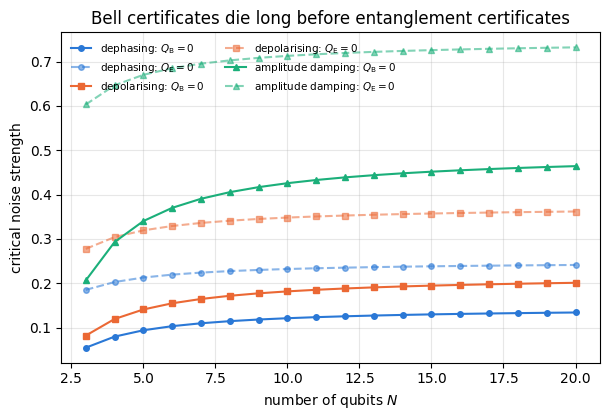

In [14]:
# ==============================================================================
# STEP 10: critical noise from Eq. (17), against the measured curves
# ==============================================================================
def p_crit_dephasing(N, which):
    """p at which Q_B (which='B') or Q_E (which='E') crosses zero for a locally dephased GHZ state."""
    expo = (2 - N) / (2 * N) if which == "B" else 1.0 / N - 1.0
    return 0.5 * (1 - 2.0 ** expo)


def p_crit_depolarising(N, which):
    expo = (2 - N) / (2 * N) if which == "B" else 1.0 / N - 1.0
    return 0.75 * (1 - 2.0 ** expo)


def g_crit_damping(N, which):
    expo = (2 - N) / N if which == "B" else 2.0 / N - 2.0
    return 1 - 2.0 ** expo


print(f"{'N':>3s} | {'dephasing':>17s} | {'depolarising':>17s} | {'amp. damping':>17s}")
print(f"{'':>3s} | {'p_B':>8s} {'p_E':>8s} | {'p_B':>8s} {'p_E':>8s} | {'g_B':>8s} {'g_E':>8s}")
Ns_crit = [3, 4, 6, 8, 10, 14, 20]
crit = {}
for N in Ns_crit:
    row = (p_crit_dephasing(N, "B"), p_crit_dephasing(N, "E"),
           p_crit_depolarising(N, "B"), p_crit_depolarising(N, "E"),
           g_crit_damping(N, "B"), g_crit_damping(N, "E"))
    crit[N] = row
    print(f"{N:3d} | {row[0]:8.4f} {row[1]:8.4f} | {row[2]:8.4f} {row[3]:8.4f} | {row[4]:8.4f} {row[5]:8.4f}")

# cross-check against the measured N = 4 sweep: interpolate where Q_B and Q_E cross zero
print(f"\ncheck at N = {N_ns} against the measured (optimised) sweep of Step 9:")
for cname, key_fn in [("dephasing", p_crit_dephasing), ("depolarising", p_crit_depolarising),
                      ("amplitude damping", g_crit_damping)]:
    qb, qe = q_values(results_ns[cname][0], N_ns)
    p_meas_B = np.interp(0.0, qb[::-1], p_grid[::-1])
    print(f"  {cname:>18s}: measured p(Q_B=0) = {p_meas_B:.4f},  Eq. (17) = {key_fn(N_ns, 'B'):.4f}")

fig, ax = plt.subplots(figsize=(6.2, 4.3))
Ns_plot = np.arange(3, 21)
for j, (lbl, fn) in enumerate([("dephasing", p_crit_dephasing), ("depolarising", p_crit_depolarising),
                               ("amplitude damping", g_crit_damping)]):
    ax.plot(Ns_plot, [fn(int(n), "B") for n in Ns_plot], MARKERS[j] + "-", ms=4, color=PALETTE[j],
            label=lbl + r": $Q_{\rm B}=0$")
    ax.plot(Ns_plot, [fn(int(n), "E") for n in Ns_plot], MARKERS[j] + "--", ms=4, color=PALETTE[j], alpha=0.55,
            label=lbl + r": $Q_{\rm E}=0$")
ax.set_xlabel("number of qubits $N$"); ax.set_ylabel("critical noise strength")
ax.set_title("Bell certificates die long before entanglement certificates")
ax.legend(fontsize=7.5, ncol=2)
fig.tight_layout(); plt.show()

The closed forms of Eq. (17) agree with the measured sweep at $N=4$ to better than $1\,\%$ in every channel: the crossings
interpolated from the optimised data are $p=0.0788$, $0.1189$ and $0.2927$ for dephasing, depolarising and amplitude
damping, against $0.0796$, $0.1193$ and $0.2929$ from Eq. (17). (The measured values are slightly *lower* because the
interpolation runs through a grid of spacing $0.05$.)

The table and the figure then say three things. First, for every channel and every $N$ the Bell threshold is well below the
entanglement threshold — at $N=6$, dephasing destroys the Bell certificate at $p=0.103$ while the coherence branch reaches
the separability bound only at $p=0.219$, a factor of $2.1$ (and, by the caveat of Section 9.2, for even $N$ under
dephasing the entanglement certificate is in fact never lost, because the second branch keeps $\mathcal E$ at or above
$4^{-N}$; the dotted $Q_{\rm E}$ curves of the previous figure flatten onto zero instead of crossing it). Second, the
thresholds **grow** with $N$ rather than shrinking, from $p_{\rm B}=0.055$
at $N=3$ to $0.134$ at $N=20$, approaching the asymptote $0.1464$ derived in Section 9.2: per qubit, a larger GHZ state
tolerates *more* dephasing, because the local-realism bound it has to beat shrinks exponentially too. Third, the ordering of
the channels is fixed: dephasing is the most damaging at equal $p$, then depolarising (which is a dephasing plus two more
error types, but with each occurring at rate $p/3$), then amplitude damping, which needs $\gamma=0.37$ at $N=6$ because it
costs the coherence only $\sqrt{1-\gamma}$ per qubit instead of $1-2p$.

> **Numerical practice.** Neither the table nor the figure needed a density tensor beyond $N=4$: the closed forms do the
> extrapolation and the simulation validates them where it can. Doing it the other way round — simulating $N=20$ to read off
> a number that a two-line calculation gives exactly — is the most common way to waste a week of computer time.

## 10. Quantum trajectories and the bias of the naive estimator

### 10.1 Why trajectories

The density tensor costs $O(4^N)$ in memory and $O(N4^N)$ per evaluation of the correlator, which is what confined Section 9
to $N\le6$. The Monte-Carlo wave-function unravelling of
[notebook 17](../ch06_open_quantum_systems/17_monte_carlo_wave_function.ipynb) replaces it by $M$ pure states of $2^N$
amplitudes each: for every trajectory one Kraus branch is sampled per qubit with probability $\lVert K_m\psi\rVert^2$, and

$$\rho=\mathbb E\bigl[\vert\psi_i\rangle\langle\psi_i\vert\bigr]\qquad\Longrightarrow\qquad
  \mathrm{Tr}(\rho\,\mathcal B)=\mathbb E\bigl[z_i\bigr],\qquad z_i=\langle\psi_i\vert\mathcal B\vert\psi_i\rangle . \tag{18}$$

The trajectory average estimates $\langle\mathcal B\rangle$, which is **linear** in $\rho$, without bias. The correlator we
want, however, is $\mathcal E=\vert\langle\mathcal B\rangle\vert^2$, which is **not** linear — and that is where the trouble
starts.

### 10.2 The bias, and its exact correction

Let $z_1,\dots,z_M$ be independent complex random variables with mean $\mu=\mathrm{Tr}(\rho\mathcal B)$ and
$\sigma^2=\mathbb E\vert z-\mu\vert^2$, and let $\bar z=\tfrac1M\sum_iz_i$. Write $\bar z=\mu+\delta$ with
$\mathbb E\delta=0$ and $\mathbb E\vert\delta\vert^2=\sigma^2/M$. Then

$$\mathbb E\vert\bar z\vert^2=\mathbb E\bigl[(\mu+\delta)\overline{(\mu+\delta)}\bigr]
 =\vert\mu\vert^2+2\,\mathrm{Re}\bigl(\bar\mu\,\mathbb E\delta\bigr)+\mathbb E\vert\delta\vert^2
 =\vert\mu\vert^2+\frac{\sigma^2}{M} . \tag{19}$$

So the naive estimator $\widehat{\mathcal E}_{\rm naive}=\vert\bar z\vert^2$ is biased **upward** by $\sigma^2/M$. The bias
is positive, it decays only as $1/M$, and it is largest exactly where it does most damage: when $\vert\mu\vert^2$ is small,
i.e. in the strong-noise region where one is trying to decide whether a bound is still violated. A naive analysis would
report a Bell violation that is not there.

The cure is exact. The sample variance

$$S^2=\frac{1}{M-1}\sum_{i=1}^{M}\vert z_i-\bar z\vert^2$$

is an unbiased estimator of $\sigma^2$ (the usual argument: $\sum_i\vert z_i-\bar z\vert^2=\sum_i\vert z_i-\mu\vert^2
-M\vert\bar z-\mu\vert^2$, whose expectation is $M\sigma^2-\sigma^2$). Subtracting Eq. (19)'s bias term,

$$\boxed{\ \widehat{\mathcal E}=\vert\bar z\vert^2-\frac{S^2}{M}\ } \tag{20}$$

is an **exactly unbiased** estimator of $\mathcal E$ for every $M>1$. It can come out slightly negative when the true
$\mathcal E$ is near zero — that is the price of unbiasedness, and the negative value is kept because clipping it at zero would reintroduce a
positive bias.

Error bars come from the **bootstrap** (Efron 1979): resample the $M$ trajectory values with replacement, recompute
Eq. (20) on each resample, and take the standard deviation of the resulting distribution. The bootstrap needs no formula
for the variance of a nonlinear statistic, which is precisely why it is the right tool here.

200 x 512 = 102400 trajectories at N = 6 in 3.4 s

exact E = 3.085258e-02   (dephasing p = 0.08, N = 6, identity angles)
    M      <naive>        bias        SE   sigma^2/M   <corrected>    residual        SE
    8  5.62500e-02  +2.540e-02  4.12e-03   2.768e-02   2.85714e-02  -2.281e-03  4.71e-03
   16  3.94727e-02  +8.620e-03  2.75e-03   1.404e-02   2.54375e-02  -5.415e-03  2.94e-03
   32  3.74072e-02  +6.555e-03  2.26e-03   6.858e-03   3.05494e-02  -3.032e-04  2.33e-03
   64  3.21899e-02  +1.337e-03  1.41e-03   3.457e-03   2.87326e-02  -2.120e-03  1.43e-03
  128  3.15903e-02  +7.377e-04  1.02e-03   1.720e-03   2.98705e-02  -9.821e-04  1.03e-03
  256  3.09650e-02  +1.124e-04  7.67e-04   8.590e-04   3.01060e-02  -7.466e-04  7.70e-04
  512  3.02527e-02  -5.999e-04  5.31e-04   4.300e-04   2.98227e-02  -1.030e-03  5.32e-04

pulls of Eq. (20): [-0.48 -1.84 -0.13 -1.49 -0.96 -0.97 -1.94]
pulls of the naive estimator: [ 6.16  3.13  2.9   0.95  0.72  0.15 -1.13]


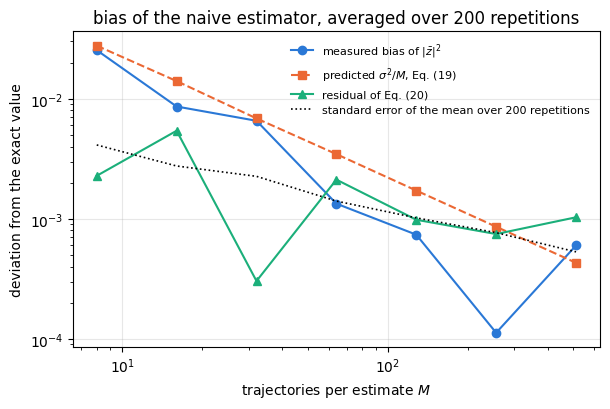

In [15]:
# ==============================================================================
# STEP 11: trajectories, the biased estimator, and Eq. (20)
# ==============================================================================
def traj_values(key, psi0, kraus, angles, n_traj):
    """z_i = <psi_i| B |psi_i> for n_traj Monte-Carlo wave-function trajectories.

    MATH   each trajectory applies one sampled Kraus branch per qubit (`apply_kraus_mcwf`), so
           E[|psi_i><psi_i|] = (channel)^{(x)N}(|psi0><psi0|)   exactly.
    JAX    one trajectory is a pure function of its key -> `vmap` over n_traj keys runs them all at once.
    COST   O(n_traj N 2^N) time and O(n_traj 2^N) memory for the batch.
    """
    N = psi0.ndim

    def one(k):
        ks = jax.random.split(k, N)
        psi = psi0
        for q in range(N):
            psi = apply_kraus_mcwf(ks[q], psi, kraus, [q])
        return bell_expectation(psi, angles)

    return jax.vmap(one)(jax.random.split(key, n_traj))


def estimators(z):
    """(naive, unbiased, sample variance) from a 1D complex array of trajectory values -- Eqs. (19)-(20)."""
    M = z.shape[0]
    zbar = jnp.mean(z)
    S2 = jnp.sum(jnp.abs(z - zbar) ** 2) / (M - 1)
    naive = jnp.abs(zbar) ** 2
    return naive, naive - S2 / M, S2


# --- the bias, measured: many independent repetitions at several M -----------
N_b, p_b = 6, 0.08
psi0_b = ghz_state(N_b)
rho_b = noisy_ghz_dm(N_b, kraus_dephasing(p_b))
E_exact_b = float(correlator_dm(rho_b, zero_angles(N_b)))

R_rep, M_max = 200, 512
t0 = time.time()
z_rep = np.asarray(jax.jit(jax.vmap(lambda k: traj_values(k, psi0_b, kraus_dephasing(p_b), zero_angles(N_b), M_max)))(
    jax.random.split(jax.random.PRNGKey(2), R_rep)))   # NOTE: not named Z -- that is the Pauli matrix
print(f"{R_rep} x {M_max} = {R_rep*M_max} trajectories at N = {N_b} in {time.time()-t0:.1f} s")

Ms = [8, 16, 32, 64, 128, 256, 512]
print(f"\nexact E = {E_exact_b:.6e}   (dephasing p = {p_b}, N = {N_b}, identity angles)")
print(f"{'M':>5s} {'<naive>':>12s} {'bias':>11s} {'SE':>9s} {'sigma^2/M':>11s} {'<corrected>':>13s} "
      f"{'residual':>11s} {'SE':>9s}")
bias_meas, bias_pred, corr_meas, sem_list, sem_corr = [], [], [], [], []
for M in Ms:
    zb = z_rep[:, :M].mean(axis=1)
    S2 = np.sum(np.abs(z_rep[:, :M] - zb[:, None]) ** 2, axis=1) / (M - 1)
    naive = np.abs(zb) ** 2
    corrected = naive - S2 / M
    sem = naive.std(ddof=1) / np.sqrt(R_rep)          # error of the AVERAGE of the naive values over R repetitions
    sem_c = corrected.std(ddof=1) / np.sqrt(R_rep)    # the same for the corrected values
    bias_meas.append(naive.mean() - E_exact_b)
    bias_pred.append(S2.mean() / M)
    corr_meas.append(corrected.mean())
    sem_list.append(sem); sem_corr.append(sem_c)
    print(f"{M:5d} {naive.mean():12.5e} {naive.mean()-E_exact_b:+11.3e} {sem:9.2e} {S2.mean()/M:11.3e} "
          f"{corrected.mean():13.5e} {corrected.mean()-E_exact_b:+11.3e} {sem_c:9.2e}")

# CHECKPOINT with a control that can fail: Eq. (20) must be consistent with zero bias at every M (3 standard errors),
# while the naive estimator at the smallest M must be detected as biased by the same test.
pull_corr = (np.array(corr_meas) - E_exact_b) / np.array(sem_corr)
pull_naive = np.array(bias_meas) / np.array(sem_list)
print(f"\npulls of Eq. (20): {np.array2string(pull_corr, precision=2)}")
print(f"pulls of the naive estimator: {np.array2string(pull_naive, precision=2)}")
assert np.all(np.abs(pull_corr) < 3.0), "Eq. (20) is biased"
assert pull_naive[0] > 4.0, "control failed: the test cannot see the naive bias at M = 8"

fig, ax = plt.subplots(figsize=(6.2, 4.2))
ax.loglog(Ms, np.abs(bias_meas), "o-", label=r"measured bias of $\vert\bar z\vert^2$")
ax.loglog(Ms, bias_pred, "s--", label=r"predicted $\sigma^2/M$, Eq. (19)")
ax.loglog(Ms, np.abs(np.array(corr_meas) - E_exact_b), "^-", label="residual of Eq. (20)")
ax.loglog(Ms, sem_list, "k:", lw=1.2, label=rf"standard error of the mean over {R_rep} repetitions")
ax.set_xlabel("trajectories per estimate $M$"); ax.set_ylabel("deviation from the exact value")
ax.set_title(rf"bias of the naive estimator, averaged over {R_rep} repetitions")
ax.legend(fontsize=8)
fig.tight_layout(); plt.show()

The naive estimator is badly biased at small $M$: at $M=8$ it returns $5.63\cdot10^{-2}$ against the exact
$3.09\cdot10^{-2}$ — **an 82 % overestimate** — and the predicted bias $2.77\cdot10^{-2}$ accounts for essentially all of
it. The bias then falls roughly as $1/M$, to $6.6\cdot10^{-3}$ at $M=32$ and $1.1\cdot10^{-4}$ at $M=256$.

"Roughly" has to be taken literally. The measured bias is itself an average over only $R=200$ repetitions, and the
column after it gives its standard error; at $M=16$ the measured $8.6\cdot10^{-3}$ sits $2.0$ standard errors below
the predicted $1.4\cdot10^{-2}$ and at $M=64$ the measured $1.3\cdot10^{-3}$ sits $1.5$ standard errors below the
predicted $3.5\cdot10^{-3}$, which is why the blue and orange curves in the figure separate by up to a factor of $2.6$
without either of them being wrong. Resolving the $1/M$ law point by point at these $M$ would need a few thousand
repetitions.

The residual of Eq. (20) — the last-but-one column, equal by construction to (measured bias) $-$ (predicted bias) — runs
from $-3\cdot10^{-4}$ to $-5.4\cdot10^{-3}$ and stays within $2.0$ of its own standard errors (last column) at every
$M$; the checkpoint requires $3$. It does not shrink with $M$, and all seven entries have the same sign, because the seven
rows of the table are nested subsets of the same $200\times512$ trajectory pool: they are seven views of one common
fluctuation and cannot count as seven independent tests. The same test applied to the naive estimator rejects it at
$M=8$ with a pull of $6.2$, which is the control showing that the checkpoint has the power to fail. So the residual of
Eq. (20) is at the noise floor of this experiment everywhere, while the bias of the naive estimator is six standard
errors above that floor at the smallest $M$.

> **Numerical practice.** Any nonlinear function of a Monte-Carlo average is biased at order $1/M$, with a coefficient set
> by the curvature of the function and the variance of the sample. Here the function is $\vert\cdot\vert^2$, the curvature
> is positive, and the bias is positive — which is the dangerous direction for a certificate. Whenever you take a modulus,
> a square, a logarithm or a ratio of Monte-Carlo estimates, ask for the $1/M$ term before you quote the number.

### 10.3 A noise sweep with trajectories and bootstrap error bars

With the estimator fixed we can go where the density tensor cannot. At $N=8$ the density tensor is already $65\,536$ complex
numbers and every optimiser evaluation touches all of them; a trajectory ensemble of $M$ states costs $M\cdot256$ numbers.
We fix the measurement angles at the GHZ optimum (Section 6.2 proved it is optimal for the noiseless state, and Section 9.3
showed that dephasing does not move it while the coherence branch dominates, i.e. for $p<0.2271$ at $N=8$), sample trajectories, and compare the corrected
estimator with the exact density-tensor value.

7 noise points x 1500 trajectories at N = 8: 6.2 s

    p        naive    corrected  bootstrap SE   exact (DM)  (corr-exact)/SE  wrong model    pull
 0.00  2.50000e-01  2.50000e-01     5.551e-17  2.50000e-01   n/a (no noise)  2.50000e-01
 0.03  1.04114e-01  1.04016e-01     6.644e-03  9.28936e-02            +1.67  1.52392e-01    -7.3
 0.06  3.14471e-02  3.13013e-02     4.339e-03  3.23342e-02            -0.24  8.99086e-02   -13.5
 0.09  8.34178e-03  8.18056e-03     2.618e-03  1.04463e-02            -0.87  5.11035e-02   -16.4
 0.12  1.82044e-03  1.65488e-03     1.154e-03  3.09712e-03            -1.25  2.78259e-02   -22.7
 0.15  2.56000e-04  8.93929e-05     4.480e-04  8.30823e-04            -1.66  1.44120e-02   -32.0
 0.20  3.00444e-04  1.33867e-04     5.419e-04  7.05277e-05            +0.12  4.19904e-03    -7.5


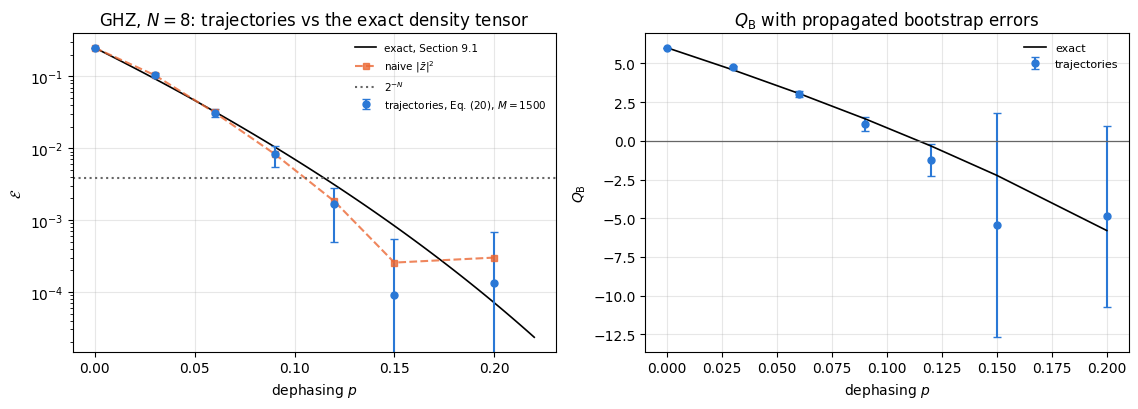

In [16]:
# ==============================================================================
# STEP 12: trajectory estimate of E(p) with bootstrap error bars, N = 8
# ==============================================================================
def bootstrap_error(key, z, n_boot=200):
    """Bootstrap standard error of the estimator (20).

    ALGORITHM  resample the M trajectory values WITH REPLACEMENT n_boot times, apply Eq. (20) to each
    resample, return the standard deviation of the resulting values.  No formula for the variance of a
    nonlinear statistic is needed -- that is the point of the bootstrap (Efron 1979).
    JAX  `jax.random.randint` draws the indices; vmap over the bootstrap replicas.
    """
    M = z.shape[0]

    def one(k):
        idx = jax.random.randint(k, (M,), 0, M)
        return estimators(z[idx])[1]

    samples = jax.vmap(one)(jax.random.split(key, n_boot))
    return jnp.std(samples)


N_tr, M_tr = 8, 1500
p_tr = np.array([0.0, 0.03, 0.06, 0.09, 0.12, 0.15, 0.20])
ang_tr = zero_angles(N_tr)
psi0_tr = ghz_state(N_tr)

traj_jit = jax.jit(traj_values, static_argnums=(4,))       # compile ONCE, outside the loop
boot_jit = jax.jit(bootstrap_error, static_argnums=(2,))

t0 = time.time()
rows_tr = []
for i, p in enumerate(p_tr):
    kr = kraus_dephasing(float(p))
    z = traj_jit(jax.random.fold_in(jax.random.PRNGKey(77), i), psi0_tr, kr, ang_tr, M_tr)
    naive, corrected, S2 = estimators(z)
    err = float(boot_jit(jax.random.fold_in(jax.random.PRNGKey(78), i), z, 200))
    exact = float(correlator_dm(noisy_ghz_dm(N_tr, kr), ang_tr))
    rows_tr.append((p, float(naive), float(corrected), err, exact))
print(f"{len(p_tr)} noise points x {M_tr} trajectories at N = {N_tr}: {time.time()-t0:.1f} s\n")

print(f"{'p':>5s} {'naive':>12s} {'corrected':>12s} {'bootstrap SE':>13s} {'exact (DM)':>12s} "
      f"{'(corr-exact)/SE':>16s} {'wrong model':>12s} {'pull':>7s}")
pulls_ok, pulls_wrong = [], []
for p, nv, co, er, ex in rows_tr:
    wrong = 0.25 * (1 - 2 * p) ** N_tr          # a plausible slip: |<B>| in place of |<B>|^2
    if er > 1e-12:
        pulls_ok.append((co - ex) / er); pulls_wrong.append((co - wrong) / er)
        print(f"{p:5.2f} {nv:12.5e} {co:12.5e} {er:13.3e} {ex:12.5e} {pulls_ok[-1]:+16.2f} {wrong:12.5e} "
              f"{pulls_wrong[-1]:+7.1f}")
    else:
        print(f"{p:5.2f} {nv:12.5e} {co:12.5e} {er:13.3e} {ex:12.5e} {'n/a (no noise)':>16s} {wrong:12.5e}")
# CHECKPOINT: the exact curve passes (all pulls within 3), the wrong model is rejected by the same data
assert np.max(np.abs(pulls_ok)) < 3.0
assert np.max(np.abs(pulls_wrong)) > 5.0, "control failed: the data cannot reject a wrong model"

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2))
p_dense = np.linspace(0, 0.22, 100)
axes[0].semilogy(p_dense, 0.25 * (1 - 2 * p_dense) ** (2 * N_tr), "k-", lw=1.2, label="exact, Section 9.1")
axes[0].errorbar(p_tr, [r[2] for r in rows_tr], yerr=[r[3] for r in rows_tr], fmt="o", ms=5, capsize=3,
                 color=PALETTE[0], label=rf"trajectories, Eq. (20), $M={M_tr}$")
axes[0].semilogy(p_tr, [r[1] for r in rows_tr], "s--", ms=5, color=PALETTE[1], alpha=0.8,
                 label="naive $\\vert\\bar z\\vert^2$")
axes[0].axhline(2.0 ** (-N_tr), color="0.4", ls=":", label=r"$2^{-N}$")
axes[0].set_xlabel(r"dephasing $p$"); axes[0].set_ylabel(r"$\mathcal{E}$")
axes[0].set_title(rf"GHZ, $N={N_tr}$: trajectories vs the exact density tensor"); axes[0].legend(fontsize=7.5)

qb_traj = q_values(np.array([max(r[2], 1e-300) for r in rows_tr]), N_tr)[0]
qb_exact = q_values(np.array([r[4] for r in rows_tr]), N_tr)[0]
err_q = np.array([r[3] for r in rows_tr]) / (np.array([max(r[2], 1e-300) for r in rows_tr]) * np.log(2))
axes[1].errorbar(p_tr, qb_traj, yerr=err_q, fmt="o", ms=5, capsize=3, color=PALETTE[0], label="trajectories")
axes[1].plot(p_tr, qb_exact, "k-", lw=1.2, label="exact")
axes[1].axhline(0, color="0.4", lw=0.9)
axes[1].set_xlabel(r"dephasing $p$"); axes[1].set_ylabel(r"$Q_{\rm B}$")
axes[1].set_title(r"$Q_{\rm B}$ with propagated bootstrap errors"); axes[1].legend(fontsize=8)
fig.tight_layout(); plt.show()

With $M=1500$ trajectories the corrected estimator agrees with the exact density-tensor value within $1.7$ bootstrap
standard errors at every noise strength; the largest pull is $+1.67$ at $p=0.03$ and the rest are below $1.7$ in absolute
value. The same data reject a plausible wrong model, $\tfrac14(1-2p)^N$ (the modulus $\vert\langle\mathcal B\rangle\vert$
mistaken for its square), with pulls between $-7$ and $-32$; that control is part of the checkpoint. Unlike the previous figure, this one is a *single* realisation at each $p$, so the bias shows up only where it is
larger than the fluctuation: at $p=0.12$ and $p=0.15$ the naive points happen to fall below the exact curve, while at
$p=0.20$ the naive estimator returns $3.0\cdot10^{-4}$ where the exact answer is $7.1\cdot10^{-5}$ — a factor of four —
because there the true signal has fallen below the $\sigma^2/M$ floor and the estimator is measuring its own variance.
The corrected value, $1.3\cdot10^{-4}\pm5.4\cdot10^{-4}$, is consistent with the exact one and
its error bar shows that the measurement cannot resolve it.

The right panel shows what that means for the certificate. The error bars on $Q_{\rm B}$ blow up exactly where
$\mathcal E$ approaches zero, because $\sigma_Q=\sigma_{\mathcal E}/(\mathcal E\ln2)$ diverges — and at the last two points
even that is optimistic, since the linearisation behind it assumes $\sigma_{\mathcal E}\ll\mathcal E$ whereas here
$\sigma_{\mathcal E}>\mathcal E$, so the plotted bar only marks the point as undefined and is no confidence interval. At
$p=0.15$ and $p=0.20$ the trajectory estimate says nothing at all about whether the bound is violated. The exact
correlator itself drops below $2^{-N}$ at $p_{\rm B}=0.1144$ (Eq. (17) at $N=8$); below that, the corrected estimate
exceeds $2^{-8}=3.9\cdot10^{-3}$ by $6.3$ standard errors at $p=0.06$ but only by $1.6$ at $p=0.09$. So $1500$
trajectories establish the violation firmly up to $p\approx0.06$, and a naive analysis that reported $Q_{\rm B}$
without error bars would have claimed more than the data contain.

## 11. One-axis twisting as a source of Bell correlations

One-axis twisting is the standard way of producing metrologically useful states in cold-atom and trapped-ion experiments:
starting from the coherent spin state $\vert+\rangle^{\otimes N}$, the Hamiltonian $\chi J_z^2$ shears the uncertainty
region on the Bloch sphere, first producing spin squeezing and eventually, at $\chi t=\pi/2$, a GHZ-like cat state
([notebooks 33 and 34](../ch10_quantum_metrology_protocols/33_spin_squeezing_one_axis_twisting.ipynb)). The evolution is
diagonal in the computational basis, so `oat_evolve` applies it exactly with no Trotter error.

Plodzien, Lewenstein, Witkowska and Chwedenczuk (2022) showed that this evolution is also a source of many-body Bell
correlations, and computed the time at which they appear: for large $N$ they find

$$\chi t_{\rm crit}\simeq\frac{2}{N}\sqrt{\frac{\pi^2}{8\ln2}-1}\approx\frac{1.77}{N} ,$$

whereas the optimal squeezing time of one-axis twisting scales as $\chi t_{\rm s}\sim N^{-2/3}$
([notebook 33](../ch10_quantum_metrology_protocols/33_spin_squeezing_one_axis_twisting.ipynb)). Since
$N^{-1}\ll N^{-2/3}$, Bell correlations are predicted to appear *before* the squeezing optimum, by a factor
$t_{\rm crit}/t_{\rm s}\sim N^{-1/3}$ that closes only slowly. We can now check that directly at one size: evaluate
$\mathcal E$ along the whole trajectory and report when each bound is crossed, alongside the Wineland squeezing
parameter $\xi^2$ so that the two resources can be compared on one axis.

One difference from the published calculation should be stated before the numbers appear. That work evaluates the
correlator in a *fixed* measurement plane (the twisting axis and one axis orthogonal to it); here every run maximises
over all $2N$ angles, as Eq. (2) prescribes. The two agree at late times — both reach $\mathcal E=1/4$ at the cat time —
but the free maximisation can only cross the bound earlier. The cell below evaluates both, the fixed-plane correlator
by setting $\theta_k=\pi/2$, $\varphi_k=0$ on every site, so that the two settings lie in the plane orthogonal to the
initial spin direction $x$.

17 OAT times at N = 8: 4.7 s

  chi t            E       Q_B       Q_E  Q_B fixed plane  xi^2 (Wineland)
 0.0000  1.52588e-05   -8.0000   -0.0000        -848.0000                1
 0.0982  9.17641e-04   -2.0898   +2.9551         -13.5341           0.5334
 0.1963  9.43618e-03   +1.2724   +4.6362          -6.0197           0.3644
 0.2945  3.40730e-02   +3.1248   +5.5624          -2.0469           0.4081
 0.3927  6.12670e-02   +3.9713   +5.9856          +0.4146           0.8137
 0.4909  7.31601e-02   +4.2272   +6.1136          +2.0002            2.307
 0.5890  7.55341e-02   +4.2733   +6.1366          +3.0273            7.655
 0.6872  7.56592e-02   +4.2757   +6.1378          +3.6860            27.94
 0.7854  7.00381e-02   +4.1643   +6.0821          +4.0004            114.4


 0.8836  5.94565e-02   +3.9280   +5.9640          +3.9280            564.2
 0.9817  4.71251e-02   +3.5926   +5.7963          +3.5911             3715
 1.0799  4.71105e-02   +3.5922   +5.7961          +3.5661        3.733e+04
 1.1781  6.65781e-02   +4.0912   +6.0456          +4.0912        6.921e+05
 1.2763  1.02779e-01   +4.7176   +6.3588          +4.7176        3.315e+07
 1.3744  1.56700e-01   +5.3261   +6.6630          +5.3261        8.644e+09
 1.4726  2.19486e-01   +5.8122   +6.9061          +5.8122        1.324e+14
 1.5708  2.50000e-01   +6.0000   +7.0000          +6.0000        2.308e+33



first grid time with Q_E > 0 (entanglement)   : chi t = 0.0982
first grid time with Q_B > 0 (Bell correlated): chi t = 0.1963
Q_B = 0 located by bisection                 : chi t = 0.1526
best squeezing xi^2 = 0.3541 at chi t = 0.2284 (dense grid of 400 points)
Q_B = 0 for the fixed-plane correlator      : chi t = 0.3728
  -> optimised correlator: Bell correlations appear before the squeezing optimum (chi t = 0.1526 vs 0.2284)
  -> fixed-plane correlator: after it (chi t = 0.3728 vs 0.2284)
at chi t = pi/2: Q_B = 6.0000 (maximum 6), Q_E = 7.0000 (maximum 7)


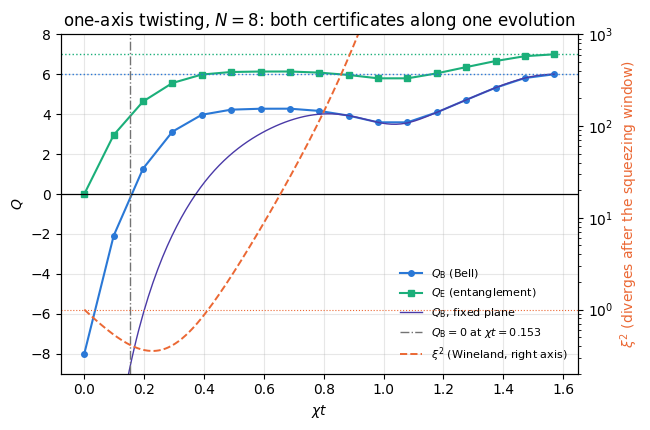

In [17]:
# ==============================================================================
# STEP 13: the correlator along the one-axis-twisting evolution
# ==============================================================================
N_oat = 8
ts_oat = np.linspace(0.0, np.pi / 2, 17)
t_dense = np.linspace(1e-4, np.pi / 2, 400)
psi_cs = product_state("+" * N_oat)
a0_oat = random_angles(jax.random.PRNGKey(123), 8, N_oat)

t0 = time.time()
oat_rows = []
for tt in ts_oat:
    psi_t = oat_evolve(psi_cs, float(tt))
    E = float(optimise_pure(psi_t, a0_oat, 200, 0.1)[0])
    xi2 = float(spin_squeezing(psi_t))
    oat_rows.append((tt, E, xi2))
print(f"{len(ts_oat)} OAT times at N = {N_oat}: {time.time()-t0:.1f} s\n")

# the fixed-plane convention of the published OAT calculation: theta = pi/2, phi = 0 on every site, no optimisation
# (rotating every qubit by pi/2 about y puts the two settings in the plane orthogonal to the initial spin direction x)
fixed_plane = lambda tt: float(correlator(oat_evolve(psi_cs, float(tt)), sym_angles(N_oat)))

print(f"{'chi t':>7s} {'E':>12s} {'Q_B':>9s} {'Q_E':>9s} {'Q_B fixed plane':>16s} {'xi^2 (Wineland)':>16s}")
for tt, E, xi2 in oat_rows:
    qb, qe = q_values(E, N_oat)
    qb_fp = q_values(fixed_plane(tt), N_oat)[0]
    print(f"{tt:7.4f} {E:12.5e} {qb:+9.4f} {qe:+9.4f} {qb_fp:+16.4f} {xi2:16.4g}")

tt_arr = np.array([r[0] for r in oat_rows])
E_arr = np.array([r[1] for r in oat_rows])
xi_arr = np.array([r[2] for r in oat_rows])
qb_arr, qe_arr = q_values(E_arr, N_oat)
first_B = tt_arr[np.argmax(qb_arr > 0)] if np.any(qb_arr > 0) else np.nan
first_E = tt_arr[np.argmax(qe_arr > 0)] if np.any(qe_arr > 0) else np.nan
best_sq = tt_arr[int(np.argmin(xi_arr))]
# locate the Q_B = 0 crossing by bisection on the optimised correlator
lo = tt_arr[np.max(np.flatnonzero(qb_arr <= 0)[np.flatnonzero(qb_arr <= 0) < np.argmax(qb_arr > 0)])]
hi = first_B
for _ in range(14):
    mid = 0.5 * (lo + hi)
    Emid = float(optimise_pure(oat_evolve(psi_cs, float(mid)), a0_oat, 200, 0.1)[0])
    if q_values(Emid, N_oat)[0] > 0:
        hi = mid
    else:
        lo = mid
t_bell = 0.5 * (lo + hi)

# the same bisection for the fixed-plane correlator (cheap: one evaluation per time, no optimiser)
lo_f, hi_f = 0.0, np.pi / 4
for _ in range(40):
    mid = 0.5 * (lo_f + hi_f)
    lo_f, hi_f = (lo_f, mid) if q_values(fixed_plane(mid), N_oat)[0] > 0 else (mid, hi_f)
t_bell_fixed = 0.5 * (lo_f + hi_f)
assert t_bell <= t_bell_fixed + 1e-3        # a maximum over the angles cannot cross the bound later

# the squeezing minimum on a dense grid (spin_squeezing is cheap -- no optimisation involved)
xi_dense = np.array([float(spin_squeezing(oat_evolve(psi_cs, float(x)))) for x in t_dense])
t_sq = t_dense[int(np.argmin(xi_dense))]

print(f"\nfirst grid time with Q_E > 0 (entanglement)   : chi t = {first_E:.4f}")
print(f"first grid time with Q_B > 0 (Bell correlated): chi t = {first_B:.4f}")
print(f"Q_B = 0 located by bisection                 : chi t = {t_bell:.4f}")
print(f"best squeezing xi^2 = {xi_dense.min():.4f} at chi t = {t_sq:.4f} (dense grid of {len(t_dense)} points)")
print(f"Q_B = 0 for the fixed-plane correlator      : chi t = {t_bell_fixed:.4f}")
print(f"  -> optimised correlator: Bell correlations appear {'before' if t_bell < t_sq else 'after'} the squeezing "
      f"optimum (chi t = {t_bell:.4f} vs {t_sq:.4f})")
print(f"  -> fixed-plane correlator: {'before' if t_bell_fixed < t_sq else 'after'} it "
      f"(chi t = {t_bell_fixed:.4f} vs {t_sq:.4f})")
print(f"at chi t = pi/2: Q_B = {qb_arr[-1]:.4f} (maximum {N_oat-2}), Q_E = {qe_arr[-1]:.4f} (maximum {N_oat-1})")

fig, ax = plt.subplots(figsize=(6.6, 4.4))
ax.plot(tt_arr, qb_arr, "o-", ms=4, color=PALETTE[0], label=r"$Q_{\rm B}$ (Bell)")
ax.plot(tt_arr, qe_arr, "s-", ms=4, color=PALETTE[2], label=r"$Q_{\rm E}$ (entanglement)")
t_fp = np.linspace(1e-3, np.pi / 2, 200)
ax.plot(t_fp, q_values(np.array([fixed_plane(x) for x in t_fp]), N_oat)[0], "-", lw=1, color=PALETTE[5],
        label=r"$Q_{\rm B}$, fixed plane")
ax.set_ylim(-9, 8)
ax.axhline(0, color="k", lw=0.9)
ax.axhline(N_oat - 2, color=PALETTE[0], ls=":", lw=1)
ax.axhline(N_oat - 1, color=PALETTE[2], ls=":", lw=1)
ax.set_xlabel(r"$\chi t$"); ax.set_ylabel(r"$Q$")
ax2 = ax.twinx()
l_xi, = ax2.semilogy(t_dense, xi_dense, "--", lw=1.4, color=PALETTE[1], label=r"$\xi^2$ (Wineland, right axis)")
ax2.set_ylabel(r"$\xi^2$ (diverges after the squeezing window)", color=PALETTE[1]); ax2.grid(False)
ax2.set_ylim(0.2, 1e3)
ax2.axhline(1.0, color=PALETTE[1], ls=":", lw=0.8)
l_bell = ax.axvline(t_bell, color="0.45", ls="-.", lw=1, label=rf"$Q_{{\rm B}}=0$ at $\chi t={t_bell:.3f}$")
ax.set_title(rf"one-axis twisting, $N={N_oat}$: both certificates along one evolution")
h, lab = ax.get_legend_handles_labels()
ax.legend(h + [l_xi], lab + [l_xi.get_label()], fontsize=8, loc="lower right")
fig.tight_layout(); plt.show()

The evolution passes three landmarks. **Entanglement** is certified immediately: $Q_{\rm E}$ is $-0.0000$ at $t=0$ (the
coherent spin state is a product state and sits exactly on the bound, as Section 6.1 requires) and already $+2.955$ at the
first grid point $\chi t=0.098$. **Bell correlations** appear at $\chi t=0.1526$, located by bisecting the optimised
$Q_{\rm B}$. **Optimal squeezing** comes later: on a dense grid of $400$ points the Wineland parameter reaches its minimum
$\xi^2=0.3541$ at $\chi t=0.2284$. So the Bell certificate switches on *before* the state is optimally squeezed — the two
resources are produced by the same interaction but peak at different times, and the squeezing optimum is not the moment at
which the state becomes most nonlocal. At $N=8$ the two times differ by only $50\,\%$, and the ordering depends on the
definition: the fixed-plane correlator of the published calculation crosses the bound only at $\chi t=0.3728$, well
*after* the squeezing optimum (the violet curve in the figure). A statement about the ordering at large $N$ therefore
rests on how the two onset times scale with $N$, compared with $\chi t_{\rm s}\sim N^{-2/3}$; one size cannot decide
it. Exercise 9 asks you to measure both scalings.

After that, $Q_{\rm B}$ rises to a local maximum of $4.276$ near $\chi t=0.69$, dips to $3.59$ around $\chi t=1.0$, and then
climbs to exactly $N-2=6$ at the cat time $\chi t=\pi/2$, where the state is a GHZ state in a rotated frame and the
algebraic maximum $\mathcal E=1/4$ is reached. The squeezing parameter, in contrast, has long since diverged: past
$\chi t\approx0.4$ the mean spin length $\vert\langle\mathbf J\rangle\vert$ collapses and $\xi^2$ runs away, which is
why the right-hand axis is clipped. At the cat time the mean spin vanishes exactly, so $\xi^2$ is undefined there; the
huge number printed in the last row of the table is a ratio of round-off errors. A quantity that measures the shape of a
small uncertainty patch on the Bloch sphere simply stops being defined once the state is a macroscopic superposition,
whereas $\mathcal E$ keeps working and reports the maximum possible value.

> **Physics insight.** The same one-axis-twisting evolution that [notebook 33](../ch10_quantum_metrology_protocols/33_spin_squeezing_one_axis_twisting.ipynb)
> uses for metrology is, at later times, a generator of many-body Bell correlations — and the certificate reaches its
> algebraic maximum exactly at the cat time that
> [notebook 34](../ch10_quantum_metrology_protocols/34_oat_to_ghz_full_metrology_protocol.ipynb) uses for Heisenberg-limited
> interferometry. One interaction, three different resources, three different optimal times.

## 12. Key takeaways

* A **Bell inequality** bounds the correlations of any local hidden-variable model, in which every party's outcome for
  every setting is a fixed function of a shared variable. For $N$ parties the correlator
  $\mathcal E=\max_U\vert\langle\bigotimes_kU_k\sigma^{-}U_k^{\dagger}\rangle\vert^2$ packages the $2^N$ correlation
  functions into one number, because $\tilde\sigma^{-}=\tfrac12(A+iB)$ with $A\perp B$ dichotomic.
* **Three bounds, all derived here**: $\mathcal E\le2^{-N}$ for every local hidden-variable model (the factors
  $\pm1\pm i$ have modulus $\sqrt2$); $\mathcal E\le4^{-m}$ for every state separable into $m$ groups (Cauchy–Schwarz plus
  the orthogonality of $\bigotimes U\vert0\rangle$ and $\bigotimes U\vert1\rangle$); and $\mathcal E\le1/4$ for every state
  whatsoever. In the logarithmic rulers of Eq. (3): $Q_{\rm B}\le0$, $Q_{\rm E}\le N-m$ (so $\le0$ for full
  separability), $Q_{\rm B}\le N-2$. Those two rulers are the $Q_N$ of Phys. Rev. Research **6**, 023050 and the
  $\mathcal Q$ of Phys. Rev. A **110**, 032428.
* **Evaluation is two array lookups.** $\sigma^{-\otimes N}=\vert1\cdots1\rangle\langle0\cdots0\vert$, so
  $\langle\mathcal B\rangle=\overline{\psi'[1\ldots1]}\,\psi'[0\ldots0]$ after $N$ single-qubit rotations: $O(N2^N)$ instead
  of $O(4^N)$, and $\rho'[0\ldots0;1\ldots1]$ for a density tensor.
* **Closed forms verified**: $\mathcal E=4^{-N}$ for $\vert+\rangle^{\otimes N}$ (the separability bound is saturated),
  $\mathcal E=1/4$ for GHZ (the algebraic maximum, $Q_{\rm B}=N-2$), $\mathcal E=\binom{N}{m}^24^{-N}$ for Dicke states,
  hence $Q_{\rm E}(W_N)=\log_2N$ and $Q_{\rm B}(W_N)=2\log_2N-N$, which is positive only for $N=3$.
* **Local-unitary invariance.** GHZ in rotated bases, the star graph state and the $T$-doped star graph all give exactly
  $\mathcal E=1/4$: the correlator is blind to local unitaries, hence to single-qubit magic, and local dephasing,
  depolarising or amplitude damping cannot reveal the $T$ gates because all three channels commute with them. The linear cluster state lands
  on $\mathcal E=2^{-N}$ ($Q_{\rm B}=0$) at $N=4$ and $N=6$ but not in general — the measured exponent in
  $\mathcal E=4^{-(1+\gamma)}$ is $\gamma=\lfloor2(N-2)/3\rfloor$ for $3\le N\le8$, so $Q_{\rm B}$ drifts down by about
  one unit per three qubits — and over $32$ Haar draws per size the mean $Q_{\rm B}$ falls from $+0.26$ at $N=4$ to
  $-0.82$ at $N=8$, with the number of violating draws going $23\to9\to0$ out of $32$. Both families are strongly entangled: this is a
  GHZ-shaped detector, and a non-positive $Q_{\rm B}$ certifies nothing.
* **Noise.** At the identity angles a locally noisy GHZ state gives $\mathcal E=\tfrac14(1-2p)^{2N}$ (dephasing),
  $\tfrac14(1-\tfrac43p)^{2N}$ (depolarising) and $\tfrac14(1-\gamma)^{N}$ (amplitude damping), all verified to $10^{-16}$.
  Free optimisation confirms the closed form for depolarising and amplitude damping at every noise strength, but **not** for
  dephasing: past $c^N=1/(2^{N-1}-1)$ ($p=0.1926$ at $N=4$) the optimum leaves the identity angles for the branch
  $\mathcal E=4^{-N}(1+c^N)^2$, $c=1-2p$, which decays onto the separability bound saturated by the classical mixture of
  $\vert0^N\rangle$ and $\vert1^N\rangle$. Seeding the restart batch with the two analytic angle choices is what makes
  the comparison one-sided; six purely random restarts land in the wrong branch near $p=0.15$.
* **Critical noise.** Eq. (17) gives it in closed form for the coherence branch; the measured $Q_{\rm B}$ crossings at
  $N=4$ agree to better than $1\,\%$. The Bell certificate is always lost first — at $N=6$, $p_{\rm B}=0.103$ against
  $p_{\rm E}=0.219$ for dephasing — and the per-qubit thresholds *increase* with $N$, towards $p_{\rm B}\to0.1464$ and
  $p_{\rm E}\to0.25$. The $p_{\rm E}$ column is a property of that branch only: for even $N$ the maximised $Q_{\rm E}$
  never becomes negative under dephasing.
* **Trajectories need a corrected estimator.** $\mathcal E$ is a *nonlinear* function of a Monte-Carlo average, so
  $\mathbb E\vert\bar z\vert^2=\vert\mu\vert^2+\sigma^2/M$: the naive estimator over-reports — by $82\,\%$ at $M=8$ in the
  measurement above, and by a factor of four at $N=8$, $p=0.20$, $M=1500$ — most severely exactly where a violation is
  marginal. $\widehat{\mathcal E}=\vert\bar z\vert^2-S^2/M$ is exactly unbiased, and the bootstrap gives error bars without
  any variance formula; with those error bars $1500$ trajectories establish the violation firmly only up to $p\approx0.06$, below the exact threshold $p_{\rm B}=0.1144$.
* **One-axis twisting** turns a coherent spin state into a Bell-correlated one. At $N=8$: $Q_{\rm E}>0$ immediately,
  $Q_{\rm B}=0$ at $\chi t=0.1526$ (bisection), best squeezing $\xi^2=0.3541$ only at $\chi t=0.2284$, and the algebraic
  maximum $Q_{\rm B}=N-2=6$ at the cat time $\chi t=\pi/2$, where $\xi^2$ has long since diverged. The ordering of the
  first two depends on the definition: with the measurement plane fixed as in the published calculation, $Q_{\rm B}$
  crosses zero only at $\chi t=0.3728$, after the squeezing optimum.

## 13. Exercises

1. ★ **The other GHZ phase.** Compute $\langle\mathcal B\rangle$ and $\mathcal E$ for
   $(\vert0\cdots0\rangle+e^{i\phi}\vert1\cdots1\rangle)/\sqrt2$ as functions of $\phi$ at the identity angles. Show
   that the phase of $\langle\mathcal B\rangle$ follows $\phi$ while $\mathcal E=1/4$ for every $\phi$, and relate this
   in one sentence to the third Euler angle of Section 5.2.
2. ★ **Where the W state loses.** Using Eq. (15), find the largest $N$ for which the W state violates the local-realism
   bound, and confirm it with the optimiser for $N=3,4,5$.
3. ★★ **Entanglement depth (extend the code).** Build the state $\vert\mathrm{GHZ}_k\rangle^{\otimes N/k}$ (several
   independent GHZ blocks of $k$ qubits) for $N=6$ and $k=2,3,6$, optimise $\mathcal E$, and check the measured values
   against the bound $\mathcal E\le4^{-N/k}$ of Section 4.3. Which $k$ does the correlator certify?
4. ★★ **A decaying SPSA schedule.** The SPSA runs of Section 7.3 use a fixed Adam learning rate. Add a cosine decay
   ($\mathrm{lr}_t=\mathrm{lr}_0\cos(\pi t/2T)$ over $T$ steps, $\mathrm{lr}_0=0.1$) and measure, for the W state and the
   $T$-doped star graph at $N=6$, how many of the $32$ restarts end within $1\,\%$ of the analytic optimum after
   $T=200$ steps, with and without the decay, with Wilson intervals.
5. ★★ **Which local unitaries survive noise.** At $N=4$, apply local dephasing, depolarising noise and amplitude damping
   to the GHZ state, the star graph and the $T$-doped star graph, and compare the optimised $\mathcal E(p)$ at
   $p=0.1$ and $p=0.3$. Explain which pairs stay equal under which channel, using that $T$ is diagonal, that the
   depolarising channel commutes with every single-qubit unitary, and that the star graph is GHZ with Hadamards on the
   leaves.
6. ★★ **Shot noise on top of trajectory noise.** Each $z_i$ in Section 10 was computed exactly. On hardware it is itself an
   average over shots. Model this by adding Gaussian noise of standard deviation $s$ to the real and imaginary parts of each
   $z_i$ and redo the bias analysis: show that Eq. (20) still removes the bias, and find how the bootstrap error bar grows
   with $s$.
7. ★★★ **The strong-dephasing plateau, and its parity.** (a) For $N=3,4,5$ build the dephased GHZ density tensor, optimise
   the angles at every $p$, and locate $p$ where $Q_{\rm B}=0$ by bisection; compare with Eq. (17). (b) Evaluate
   $\mathcal E$ for the classical mixture $\tfrac12(\vert0^N\rangle\langle0^N\vert+\vert1^N\rangle\langle1^N\vert)$ by free
   optimisation for $N=3,\dots,6$ and check the derivation of Section 9.3: the plateau is $4^{-N}$ for even $N$ and
   $0$ for odd $N$. Does the $p\to\tfrac12$ limit of the optimised dephasing curve reproduce that parity?
8. ★★★ **Graph states beyond the star.** Compute $\mathcal E$ for the linear cluster state, the ring cluster state and the
   complete-graph state for $N=4,\dots,7$. Which graphs reach $\mathcal E=1/4$, and can you relate the answer to whether the
   graph is local-Clifford equivalent to a star? (Answer for the complete graph: it is, so $\mathcal E=1/4$ at every $N$.)
9. ★★★ **The two time scales of one-axis twisting.** Repeat Section 11 for $N=8,12,16$ and locate, for each, the time at
   which the optimised $Q_{\rm B}$ crosses zero, the time at which the fixed-plane $Q_{\rm B}$ crosses zero, and the time of
   minimal $\xi^2$. Fit the three to power laws in $N$ (the fixed-plane curve is cheap enough to follow up to $N=20$ on a
   state vector) and compare exponents and prefactors with each other, with $\chi t_{\rm s}\propto N^{-2/3}$ and with
   the large-$N$ estimate $\chi t_{\rm crit}\approx1.77/N$ quoted at the start of Section 11. At which $N$ does each
   onset move ahead of the squeezing optimum? (At $N=16$ and short times $\mathcal E$ is so small that Adam on
   $\mathcal E$ itself can stall at the seeded value $4^{-N}$; maximise $\log\mathcal E$ instead.)

## 14. References

* J. S. Bell, *On the Einstein Podolsky Rosen paradox*, Physics Physique Fizika **1**, 195 (1964) — the original theorem.
* J. F. Clauser, M. A. Horne, A. Shimony and R. A. Holt, *Proposed experiment to test local hidden-variable theories*,
  Phys. Rev. Lett. **23**, 880 (1969) — the CHSH inequality of Section 3.2.
* B. S. Cirel'son, *Quantum generalizations of Bell's inequality*, Lett. Math. Phys. **4**, 93 (1980) — the bound
  $2\sqrt2$.
* N. D. Mermin, *Extreme quantum entanglement in a superposition of macroscopically distinct states*,
  Phys. Rev. Lett. **65**, 1838 (1990) — $N$-party Bell inequalities violated exponentially by GHZ states.
* M. Zukowski and C. Brukner, *Bell's theorem for general N-qubit states*, Phys. Rev. Lett. **88**, 210401 (2002) — the
  general family of two-setting $N$-party inequalities mentioned in Section 3.3.
* E. G. Cavalcanti, C. J. Foster, M. D. Reid and P. D. Drummond, *Bell inequalities for continuous-variable correlations*,
  Phys. Rev. Lett. **99**, 210405 (2007) — the CFRD inequalities built from complex combinations of two local observables,
  of which Eq. (8) is the qubit case.
* E. G. Cavalcanti, Q. Y. He, M. D. Reid and H. M. Wiseman, *Unified criteria for multipartite quantum nonlocality*,
  Phys. Rev. A **84**, 032115 (2011), arXiv:1008.5014 — the family
  $\vert\langle\prod_j(X_j+iY_j)\rangle\vert\le2^{(N-T)/2}$ that contains both bounds of Section 4 as the cases $T=0$
  and $T=N$, and the steering criteria in between.
* J. Chwedenczuk, *Many-body Bell inequalities for bosonic qubits*, SciPost Phys. Core **5**, 025 (2022),
  arXiv:2109.15156 — the correlator of Eq. (1), the Cauchy–Schwarz derivation of the bound $2^{-N}$, and the version for
  indistinguishable particles.
* A. Niezgoda and J. Chwedenczuk, *Many-body nonlocality as a resource for quantum-enhanced metrology*,
  Phys. Rev. Lett. **126**, 210506 (2021), arXiv:2011.06612 — the same correlator, and the bound
  $F_Q>N^2/2^{n+1}$ on the quantum Fisher information when at least $N-n$ qubits are Bell correlated.
* M. Plodzien, M. Lewenstein, E. Witkowska and J. Chwedenczuk, *One-axis twisting as a method of generating many-body Bell
  correlations*, Phys. Rev. Lett. **129**, 250402 (2022), arXiv:2206.10542 — the physics of Section 11, including the
  onset time $\chi t_{\rm crit}\approx1.77/N$ and the value $\mathcal E=1/4$ at the cat time.
* M. Plodzien, T. Wasak, E. Witkowska, M. Lewenstein and J. Chwedenczuk, *Generation of scalable many-body Bell
  correlations in spin chains with short-range two-body interactions*, Phys. Rev. Research **6**, 023050 (2024),
  arXiv:2306.06173 — the same correlator for short-range spin chains; its Eq. (3) defines the quantity written
  $Q_{\rm B}$ here through $\mathcal E_N\equiv2^{Q_N-N}$.
* M. Plodzien, J. Chwedenczuk, M. Lewenstein and G. Rajchel-Mieldzioc, *Entanglement classification and non-k-separability
  certification via Greenberger-Horne-Zeilinger-class fidelity*, Phys. Rev. A **110**, 032428 (2024), arXiv:2406.10662 —
  the quantity written $Q_{\rm E}$ here (its $\mathcal Q=\log_4(4^N\mathcal E)$) and the $k$-separability bound
  $\mathcal Q\le N-k$, which is Eq. (10) of Section 4.3.
* M. Plodzien, M. Lewenstein and J. Chwedenczuk, *Many-body quantum resources of graph states*,
  Rep. Prog. Phys. **88**, 077601 (2025), arXiv:2410.12487 — graph states as in Section 8 and a classification of their
  Bell correlations; there the maximisation in Eq. (2) is restricted to the three Pauli frames per site.
* J. C. Spall, *Multivariate stochastic approximation using a simultaneous perturbation gradient approximation*,
  IEEE Trans. Autom. Control **37**, 332 (1992) — SPSA.
* D. P. Kingma and J. Ba, *Adam: a method for stochastic optimization*, arXiv:1412.6980, ICLR 2015 — the optimiser.
* B. Efron, *Bootstrap methods: another look at the jackknife*, Ann. Statist. **7**, 1 (1979) — the error bars of
  Section 10.
* M. Kitagawa and M. Ueda, *Squeezed spin states*, Phys. Rev. A **47**, 5138 (1993) — one-axis twisting.
* D. J. Wineland, J. J. Bollinger, W. M. Itano and D. J. Heinzen, *Squeezed atomic states and projection noise in
  spectroscopy*, Phys. Rev. A **50**, 67 (1994) — the squeezing parameter $\xi^2$ plotted in Section 11.

---
Marcin Płodzień, PhD

**Citation:** M. Płodzień, *Quantum Many-Body Simulation: from a single spin to quantum machine learning* (2026), https://marcinplodzien.github.io/quantum-many-body-simulation/